# Sixteen Boolean Functions, and Two Ways to Fail at Them

**Sidney Harrell**<br>
Senior Sysadmin, Support Dept.<br>
[www.valiantysfederal.com](https://www.valiantysfederal.com)<br>
*with help from Claude Opus 5*

## Abstract

A two-input boolean function, such as XOR, maps 2 input bits to 1 output bit. An enumeration over all combinations of input bits can be represented 
visually as a 2x2 grid, with four cells. Each cell could output a 0 or a 1, so there are exactly $2^4 = 16$ of them. This notebook trains one small 
network per function and uses that complete, tiny problem space as an instrument for 
a larger question: when a network fails to learn something, how do you tell whether the 
failure was a result of the *architecture* or of the *training*?

Part 1 establishes a baseline - sixteen `2 -> 8 (ReLU) -> 1` networks, all sixteen
functions learned exactly. Part 2 narrows the hidden layer to 4, 2, and 1 units and
watches accuracy fall to 52/64, then asks what actually broke. The answer is not the
obvious one: only 2 of the 12 failures are true capacity limits, and 9 are recovered
by nothing more than a different random seed. The dominant failure is **dead ReLU
units**, which Part 3 confirms by plotting the loss surface directly - the dead
region is a perfectly flat plateau, its loss varying by exactly `0.00e+00`. Part 4
tests the resulting hypothesis by swapping ReLU for `tanh`, whose derivative is
never zero: every dead layer disappears (9 to 0) and accuracy rises to 61/64, while
the two provable capacity limits survive untouched, consistent with the hypothesis -
if a failure is architectural rather than parametric, changing parameters will not fix the failure.

Part 4 also stress-tests the one claim Part 2 left open, and width 2 *does* learn
`XOR` - in 2 of 12 hyperparameter configurations, and at the baseline learning rate as
well once the search runs past the first five seeds. That failure belonged to the
recipe. Part 5 then opens the trained networks up. Ablation shows each width-8 solution
uses a mean of 1.38 of its 8 hidden units, and the `XOR` circuits read straight off the
weights: at width 8 a positive output bias answering 1 by default, vetoed by one group
of units detecting `00` and another detecting `11`; at width 2, two units pointing in
the same direction and differing only in bias, which is two kinks on a single axis
where one kink provably cannot suffice.

## Preface

**What this is.** An exploration in a small problem space. Because there are only
16 two-input boolean functions and each has only 4 training rows, every claim here
can be checked exhaustively rather than sampled - and the exact optima can often be
derived by hand and compared against what training actually finds.
This environment acts as a natural playground for the philosophy shared by Keith Duggar on the MLST podcast: "Scientists leverage control to gain knowledge. Engineers leverage knowledge to gain control."

**How to run it.** Cells are strictly sequential - later parts reuse models and
results from earlier ones, so run top to bottom. Everything is deterministic given
the seeds: `torch.manual_seed(42)` for Parts 1 and 2, with Parts 3 and 4 stating
their own seeds where it matters.

The full notebook takes roughly **35-40 minutes on a consumer grade GPU**, dominated by
two sweeps of 16 models x 4 widths and the hyperparameter grid in Part 4. It runs
unchanged on CPU, just more slowly. At this size the GPU is bound by kernel-launch
latency rather than arithmetic - the measured rate is about 0.75 ms per step regardless
of hidden width, since a 33-parameter model does not meaningfully load an RTX 4060.

**The five parts.**

| Part | Question | Answer |
|:--|:--|:--|
| **1** | Can a small network learn all 16 functions? | Yes - 16/16, 64/64 bits |
| **2** | What breaks as the hidden layer narrows? | Mostly dead units, not capacity |
| **3** | What does "dead" look like on the loss surface? | An exactly flat plateau |
| **4** | Can the failed runs be fixed? | Yes, all but the two proved limits |
| **5** | What do the solved networks compute? | Circuits you can read off the weights |

**A note on how the results are stated.** Where a claim can be proved, it is proved
and then asserted in code - the assertions check the *theory*, so a bug loud enough
to break the theory fails the notebook rather than quietly producing a plausible
number. Where a claim is only observed, it is labelled as observed, and the summary
cells compute their own text from the data so the prose cannot drift out of step
with the results.

## Two Kinds of Failure

Everything below turns on one distinction, so it is worth stating precisely. When a network does not learn a function, exactly one of two
things is true.

|  | Capacity problem | Optimisation problem |
|:--|:--|:--|
| **Claim** | No weights exist that compute it | Weights exist; training didn't reach them |
| **Fix** | Change the architecture | Change init, seed, lr, activation — or just retry |
| **Effect of more epochs** | None, ever | Sometimes |

"Capacity" here means **representational** capacity - whether *any* setting of the
weights is able to compute the target. Capacity and trainability are independent: a
model can have ample capacity and still fail to train, which we will see in Part 2.

**The evidence for each kind is asymmetric.**
Finding a seed that succeeds *disproves* a capacity limit outright - one example is
enough. Failing on many seeds proves nothing, because it is equally consistent with
either explanation. So a capacity claim needs a **proof**, never a run of bad luck.
That is why Part 2 proves its impossibility result algebraically instead of
concluding it from 4 failed retries, and why Part 4 re-checks the same proof against
a different activation.

By the end, this notebook contains one clean example of each, plus a third case that
took a dedicated experiment to classify:

- **Capacity** - `XOR` and `XNOR` at width 1. Proved impossible for *any* monotone
  activation, so no seed, epoch budget, or nonlinearity can help.
- **Optimisation** - the dead-ReLU failures. The solution exists; training froze on a
  flat plateau. Fixed by a different seed, or by changing the activation.
- **The case in between** - `XOR` at width 2. Provably representable, and not reached
  by the recipe Part 2 used. Part 4 searches wider - other seeds, learning rates and
  budgets - and does reach it, which puts the case in the optimisation column after
  all. Capacity is necessary but not sufficient, and failing to reach a solution is
  not by itself evidence about capacity.

---

# Part 1 - The Baseline: All Sixteen, Learned Exactly

Before anything can be said about failure, there has to be a working case. Part 1
trains sixteen independent `2 -> 8 (ReLU) -> 1 (Sigmoid)` networks, one per boolean
function, and verifies that each one reproduces its truth table bit for bit.

`XOR` and `XNOR` are the two functions that are not linearly separable, so they are
the only two where the hidden layer is doing work that a single neuron could not do
in principle. The other 14 are linearly separable, meaning one neuron *could*
represent them - though Part 2 shows that "could represent" and "will learn" come
apart more often than expected.

## 1.1 Imports and device setup

In [1]:
import itertools
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display

# Seed before anything random happens; re-seeded in the training cell as well so
# model initialisation is reproducible no matter which order cells are run in.
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"torch        : {torch.__version__}")
print(f"cuda runtime : {torch.version.cuda}")
print(f"cuda avail   : {torch.cuda.is_available()}")
print(f"device       : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"gpu          : {torch.cuda.get_device_name(0)}")
    print(f"capability   : sm_{''.join(map(str, torch.cuda.get_device_capability(0)))}")

torch        : 2.3.0
cuda runtime : 12.1
cuda avail   : True
device       : cuda
gpu          : NVIDIA GeForce RTX 4060
capability   : sm_89


## 1.2 Truth table data

Here we generate the 16 truth tables that the neural nets will be trained and tested against.

`INPUTS` is the shared `(4, 2)` tensor of all `(A, B)` combinations, ordered
`00, 01, 10, 11`. Each function gets its own `(4, 1)` targets tensor.

The functions are defined by formula rather than by hard-coded bit patterns, then
cross-checked against `itertools.product` to prove all 16 distinct functions are
present with none repeated. Note the two conventions worth stating explicitly:

- `A_INHIBITS_B` is *A and not B* (A present, B suppressed)
- `A_IMPLIES_B` is *not A or B* (material implication)

In [2]:
# All (A, B) combinations: 00, 01, 10, 11
INPUTS = torch.tensor(
    list(itertools.product([0, 1], repeat=2)),
    dtype=torch.float32,
    device=DEVICE,
)

# Each function as a formula over ints in {0, 1}. NOT x is written 1 - x because
# Python's ~ operator on ints is two's-complement (~0 == -1), not boolean NOT.
FUNCTION_DEFS = [
    ("CONSTANT_0",   lambda a, b: 0),
    ("AND",          lambda a, b: a & b),
    ("A_INHIBITS_B", lambda a, b: a & (1 - b)),
    ("IDENTITY_A",   lambda a, b: a),
    ("B_INHIBITS_A", lambda a, b: b & (1 - a)),
    ("IDENTITY_B",   lambda a, b: b),
    ("XOR",          lambda a, b: a ^ b),
    ("OR",           lambda a, b: a | b),
    ("NOR",          lambda a, b: 1 - (a | b)),
    ("XNOR",         lambda a, b: 1 - (a ^ b)),
    ("NOT_B",        lambda a, b: 1 - b),
    ("B_IMPLIES_A",  lambda a, b: a | (1 - b)),
    ("NOT_A",        lambda a, b: 1 - a),
    ("A_IMPLIES_B",  lambda a, b: (1 - a) | b),
    ("NAND",         lambda a, b: 1 - (a & b)),
    ("CONSTANT_1",   lambda a, b: 1),
]

TRUTH_TABLES = {}
for name, fn in FUNCTION_DEFS:
    bits = [fn(int(a), int(b)) for a, b in INPUTS.tolist()]
    TRUTH_TABLES[name] = torch.tensor(
        bits, dtype=torch.float32, device=DEVICE
    ).view(-1, 1)

# Sanity check: 16 functions, all distinct, covering every 4-bit output pattern.
patterns = {tuple(t.flatten().int().tolist()) for t in TRUTH_TABLES.values()}
assert len(TRUTH_TABLES) == 16, f"expected 16 functions, got {len(TRUTH_TABLES)}"
assert len(patterns) == 16, "duplicate output patterns - some function is repeated"
assert patterns == set(itertools.product([0, 1], repeat=4)), "not all 16 patterns covered"

# The only two that are not linearly separable - the reason a hidden layer exists.
NONLINEAR = ["XOR", "XNOR"]

print(f"INPUTS shape  : {tuple(INPUTS.shape)}  on {INPUTS.device}")
print(f"targets shape : {tuple(next(iter(TRUTH_TABLES.values())).shape)} each")
print(f"functions     : {len(TRUTH_TABLES)} (all 16 distinct patterns verified)\n")

truth_df = pd.DataFrame(
    {name: t.flatten().int().cpu().numpy() for name, t in TRUTH_TABLES.items()},
    index=[f"A={int(a)} B={int(b)}" for a, b in INPUTS.tolist()],
)
display(truth_df)

INPUTS shape  : (4, 2)  on cuda:0
targets shape : (4, 1) each
functions     : 16 (all 16 distinct patterns verified)



,CONSTANT_0,AND,A_INHIBITS_B,IDENTITY_A,B_INHIBITS_A,IDENTITY_B,XOR,OR,NOR,XNOR,NOT_B,B_IMPLIES_A,NOT_A,A_IMPLIES_B,NAND,CONSTANT_1
A=0 B=0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1
A=0 B=1,0,0,0,0,1,1,1,1,0,0,0,0,1,1,1,1
A=1 B=0,0,0,1,1,0,0,1,1,0,0,1,1,0,0,1,1
A=1 B=1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1


The same 16 functions again, but drawn one 2x2 grid each - rows are `A`, columns are
`B`, so the cell at row `A=1`, column `B=0` is the output for input `(1, 0)`.

This layout makes linear separability visible by eye. A function is
linearly separable when you can draw a single straight line anywhere through the 2x2 square
with all the `1`s on one side. `XOR` and `XNOR` are the two where the `1`s sit on
opposite *diagonals*, and no straight line separates a diagonal pair - which is
precisely why those two need a hidden layer.

In [3]:
def truth_grid(name, targets, inner_width=16):
    """Render one function as a 2x2 grid: rows are A, columns are B."""
    bits = [int(v) for v in targets.flatten().tolist()]   # order 00, 01, 10, 11
    label = name + (" *" if name in NONLINEAR else "")

    body = [
        "      B=0 B=1",
        f" A=0   {bits[0]}   {bits[1]}",
        f" A=1   {bits[2]}   {bits[3]}",
    ]
    return (
        ["\u250c\u2500 " + label + " " + "\u2500" * (inner_width - len(label) - 3) + "\u2510"]
        + ["\u2502" + line.ljust(inner_width) + "\u2502" for line in body]
        + ["\u2514" + "\u2500" * inner_width + "\u2518"]
    )


blocks = [truth_grid(name, targets) for name, targets in TRUTH_TABLES.items()]

# Four grids per row, so all 16 fit in one readable block.
for start in range(0, len(blocks), 4):
    row = blocks[start:start + 4]
    for line_no in range(len(row[0])):
        print("   ".join(block[line_no] for block in row))
    print()

print(f"* = not linearly separable ({', '.join(NONLINEAR)}): "
      f"the 1s lie on a diagonal, so no single straight line separates them.")

┌─ CONSTANT_0 ───┐   ┌─ AND ──────────┐   ┌─ A_INHIBITS_B ─┐   ┌─ IDENTITY_A ───┐
│      B=0 B=1   │   │      B=0 B=1   │   │      B=0 B=1   │   │      B=0 B=1   │
│ A=0   0   0    │   │ A=0   0   0    │   │ A=0   0   0    │   │ A=0   0   0    │
│ A=1   0   0    │   │ A=1   0   1    │   │ A=1   1   0    │   │ A=1   1   1    │
└────────────────┘   └────────────────┘   └────────────────┘   └────────────────┘

┌─ B_INHIBITS_A ─┐   ┌─ IDENTITY_B ───┐   ┌─ XOR * ────────┐   ┌─ OR ───────────┐
│      B=0 B=1   │   │      B=0 B=1   │   │      B=0 B=1   │   │      B=0 B=1   │
│ A=0   0   1    │   │ A=0   0   1    │   │ A=0   0   1    │   │ A=0   0   1    │
│ A=1   0   0    │   │ A=1   0   1    │   │ A=1   1   0    │   │ A=1   1   1    │
└────────────────┘   └────────────────┘   └────────────────┘   └────────────────┘

┌─ NOR ──────────┐   ┌─ XNOR * ───────┐   ┌─ NOT_B ────────┐   ┌─ B_IMPLIES_A ──┐
│      B=0 B=1   │   │      B=0 B=1   │   │      B=0 B=1   │   │      B=0 B=1   │
│ A=0   1   0 

## 1.3 Model definition

One class, one hidden layer, width configurable. `Sigmoid` on the output because
`BCELoss` expects probabilities in `(0, 1)`.

The activation is also configurable, defaulting to `ReLU`. Parts 1-3 use the default
throughout; only Part 4 changes it, and it does so through this same class so that
the two activations are compared through identical code.

In [4]:
ACTIVATIONS = {"relu": nn.ReLU, "tanh": nn.Tanh}


class BooleanNet(nn.Module):
    """2 -> hidden -> 1 (Sigmoid) classifier for a single boolean function.

    The hidden nonlinearity is configurable so Part 4 can swap ReLU for Tanh; the
    layer indices are unchanged either way, so net[0] and net[2] are always the two
    Linear layers and net[1] is always the activation.
    """

    def __init__(self, hidden_width: int = 8, activation: str = "relu"):
        super().__init__()
        self.activation = activation
        self.net = nn.Sequential(
            nn.Linear(2, hidden_width),
            ACTIVATIONS[activation](),
            nn.Linear(hidden_width, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


_demo = BooleanNet()
print(_demo)
print(f"\ntrainable parameters per model: {sum(p.numel() for p in _demo.parameters())}")
del _demo

BooleanNet(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=1, bias=True)
    (3): Sigmoid()
  )
)

trainable parameters per model: 33


A quick picture of the same thing. `draw_network` takes the width as an argument,
so the shrinking layers of Part 2 can be drawn with `draw_network(2)` and friends.

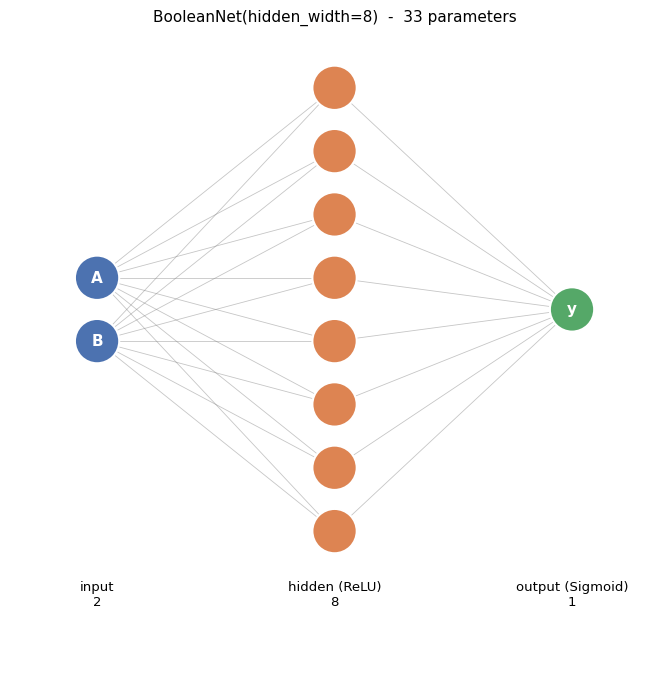

In [5]:
def draw_network(hidden_width=8, ax=None, show_title=True, activation="ReLU"):
    """Sketch the 2 -> hidden -> 1 architecture as a node/edge diagram."""
    X_GAP, Y_GAP, RADIUS = 3.0, 0.8, 0.28

    sizes = [2, hidden_width, 1]
    node_labels = [["A", "B"], [""] * hidden_width, ["y"]]
    colors = ["#4C72B0", "#DD8452", "#55A868"]
    captions = ["input\n2", f"hidden ({activation})\n{hidden_width}",
                "output (Sigmoid)\n1"]

    # Node positions: one column per layer, centred on y=0 and ordered top-down
    # so the input nodes read A, B rather than B, A.
    positions = []
    for i, n in enumerate(sizes):
        ys = np.linspace((n - 1) / 2, -(n - 1) / 2, n) * Y_GAP
        positions.append([(i * X_GAP, y) for y in ys])

    half_height = max((n - 1) / 2 * Y_GAP for n in sizes) + RADIUS
    top, bottom = half_height + 0.45, -half_height - 1.5
    left, right = -1.1, 2 * X_GAP + 1.1

    if ax is None:
        # Equal aspect would letterbox a mismatched figsize, so derive it.
        width_in = 7.0
        _, ax = plt.subplots(
            figsize=(width_in, width_in * (top - bottom) / (right - left)))

    # Fully connected edges between consecutive layers.
    for lhs, rhs in zip(positions, positions[1:]):
        for x1, y1 in lhs:
            for x2, y2 in rhs:
                ax.plot([x1, x2], [y1, y2], color="grey",
                        linewidth=0.6, alpha=0.45, zorder=1)

    for pts, color, labels, caption in zip(positions, colors, node_labels, captions):
        for (x, y), label in zip(pts, labels):
            ax.add_patch(plt.Circle((x, y), RADIUS, color=color,
                                    ec="white", linewidth=1.5, zorder=2))
            if label:
                ax.text(x, y, label, ha="center", va="center", color="white",
                        fontsize=11, fontweight="bold", zorder=3)
        ax.text(pts[0][0], -half_height - 0.35, caption,
                ha="center", va="top", fontsize=9.5)

    if show_title:
        ax.set_title(f"BooleanNet(hidden_width={hidden_width})  -  "
                     f"{4 * hidden_width + 1} parameters", fontsize=11)

    ax.set_xlim(left, right)
    ax.set_ylim(bottom, top)
    ax.set_aspect("equal")
    ax.axis("off")
    return ax


draw_network()          # default width 8, as used throughout Part 1
plt.tight_layout()
plt.show()

## 1.4 Training

16 independent models, 10,000 full-batch epochs each. With only 4 rows per step
there is no reason to involve a `DataLoader` - the whole dataset is one batch and
already resident on the GPU, so each epoch is a single forward/backward pass.

At this size the GPU is latency-bound on kernel launches rather than compute; the
work per step is tiny.

Loss sampling is **dense early and sparse later**: every epoch for the first 500,
then every 50. Calling `.item()` forces a device-to-host sync, so sampling every
epoch for the full run would be wasteful - but all the interesting dynamics happen
in the first few hundred epochs, and sampling them at 1-in-50 makes the curves
useless to zoom into.

In [6]:
HIDDEN_WIDTH = 8
EPOCHS = 10_000
LEARNING_RATE = 0.01
LOSS_EVERY = 50
EARLY_DENSE = 500      # record every epoch below this, then every LOSS_EVERY


def record_loss_at(epoch, epochs, loss_every=LOSS_EVERY, early_dense=EARLY_DENSE):
    """Sample densely where the curve actually moves, sparsely once it flattens."""
    return epoch < early_dense or epoch % loss_every == 0 or epoch == epochs - 1


# Re-seed here so model init is reproducible independent of cell execution order.
torch.manual_seed(42)
models = {name: BooleanNet(HIDDEN_WIDTH).to(DEVICE) for name in TRUTH_TABLES}

criterion = nn.BCELoss()
loss_history = {}

print(f"training {len(models)} models x {EPOCHS:,} epochs on {DEVICE}\n")
wall_start = time.perf_counter()

for name, model in models.items():
    targets = TRUTH_TABLES[name]
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    history = []

    model.train()
    t0 = time.perf_counter()
    for epoch in range(EPOCHS):
        optimizer.zero_grad()
        outputs = model(INPUTS)              # full batch: all 4 rows at once
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        if record_loss_at(epoch, EPOCHS):
            history.append((epoch, loss.item()))

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    loss_history[name] = history
    print(f"{name:<14} final loss = {history[-1][1]:.3e}   ({elapsed:5.1f}s)")

total = time.perf_counter() - wall_start
print(f"\ntotal training time: {total:.1f}s "
      f"({total / (len(models) * EPOCHS) * 1e3:.3f} ms/step)")

training 16 models x 10,000 epochs on cuda



CONSTANT_0     final loss = 4.581e-08   ( 11.3s)


AND            final loss = 5.886e-07   ( 11.4s)


A_INHIBITS_B   final loss = 5.596e-07   ( 10.7s)


IDENTITY_A     final loss = 8.043e-06   ( 10.5s)


...

B_IMPLIES_A    final loss = 5.788e-07   ( 10.9s)


NOT_A          final loss = 5.900e-07   ( 11.0s)


A_IMPLIES_B    final loss = 6.637e-07   ( 11.2s)


NAND           final loss = 7.619e-07   ( 11.5s)


CONSTANT_1     final loss = 2.384e-07   ( 12.2s)

total training time: 176.6s (1.104 ms/step)


## 1.5 Evaluation

Inference on all 4 rows for every model, sigmoid output rounded to the nearest
integer. `margin` is the smallest distance between any of the 4 raw sigmoid
outputs and the 0.5 decision boundary - a large margin means the model is
confidently right.

In [7]:
rows = []
for name, model in models.items():
    target = TRUTH_TABLES[name].flatten()

    model.eval()
    with torch.no_grad():
        probs = model(INPUTS).flatten()

    preds = probs.round()
    correct_bits = int((preds == target).sum().item())
    margin = float((probs - 0.5).abs().min().item())

    fmt = lambda t: " ".join(str(int(v)) for v in t.tolist())
    rows.append({
        "function": name,
        "target": fmt(target),
        "predicted": fmt(preds),
        "bits": f"{correct_bits}/4",
        "margin": round(margin, 6),   # max possible is 0.5 (fully saturated sigmoid)
        "result": "PASS" if correct_bits == 4 else "FAIL",
    })

results = pd.DataFrame(rows)
display(results)

# --- assertions -----------------------------------------------------------
failures = results.loc[results["result"] != "PASS", "function"].tolist()
assert not failures, f"models failed to learn their truth table: {failures}"
assert len(results) == 16, f"expected 16 results, got {len(results)}"

total_bits = 4 * len(results)
correct_bits = sum(int(b.split("/")[0]) for b in results["bits"])
assert correct_bits == total_bits, f"only {correct_bits}/{total_bits} bits correct"

print(f"\nSUMMARY")
print(f"  functions passed : {len(results)}/16")
print(f"  bit accuracy     : {correct_bits}/{total_bits} (100.00%)")
print(f"  weakest margin   : {results['margin'].min():.6f} of 0.5 max "
      f"({results.loc[results['margin'].idxmin(), 'function']})")
print(f"  worst final loss : {max(h[-1][1] for h in loss_history.values()):.3e}")
print(f"  device           : {DEVICE}")
print(f"\n  All 16 two-input boolean functions learned exactly.")

,function,target,predicted,bits,margin,result
0,CONSTANT_0,0 0 0 0,0 0 0 0,4/4,0.500000,PASS
1,AND,0 0 0 1,0 0 0 1,4/4,0.499999,PASS
2,A_INHIBITS_B,0 0 1 0,0 0 1 0,4/4,0.499999,PASS
3,IDENTITY_A,0 0 1 1,0 0 1 1,4/4,0.499985,PASS
4,B_INHIBITS_A,0 1 0 0,0 1 0 0,4/4,0.499999,PASS
5,IDENTITY_B,0 1 0 1,0 1 0 1,4/4,0.499999,PASS
6,XOR,0 1 1 0,0 1 1 0,4/4,0.499967,PASS
7,OR,0 1 1 1,0 1 1 1,4/4,0.499998,PASS
8,NOR,1 0 0 0,1 0 0 0,4/4,0.499999,PASS
9,XNOR,1 0 0 1,1 0 0 1,4/4,0.499999,PASS



SUMMARY
  functions passed : 16/16
  bit accuracy     : 64/64 (100.00%)
  weakest margin   : 0.499967 of 0.5 max (XOR)
  worst final loss : 1.738e-05
  device           : cuda

  All 16 two-input boolean functions learned exactly.


## 1.6 Loss curves

Log-scale y axis, since the losses span several orders of magnitude. `XOR` and
`XNOR` are highlighted as the two non-separable functions, but read the curves before
assuming that makes them the slow ones - the numbers below are more equivocal than
the usual story suggests.

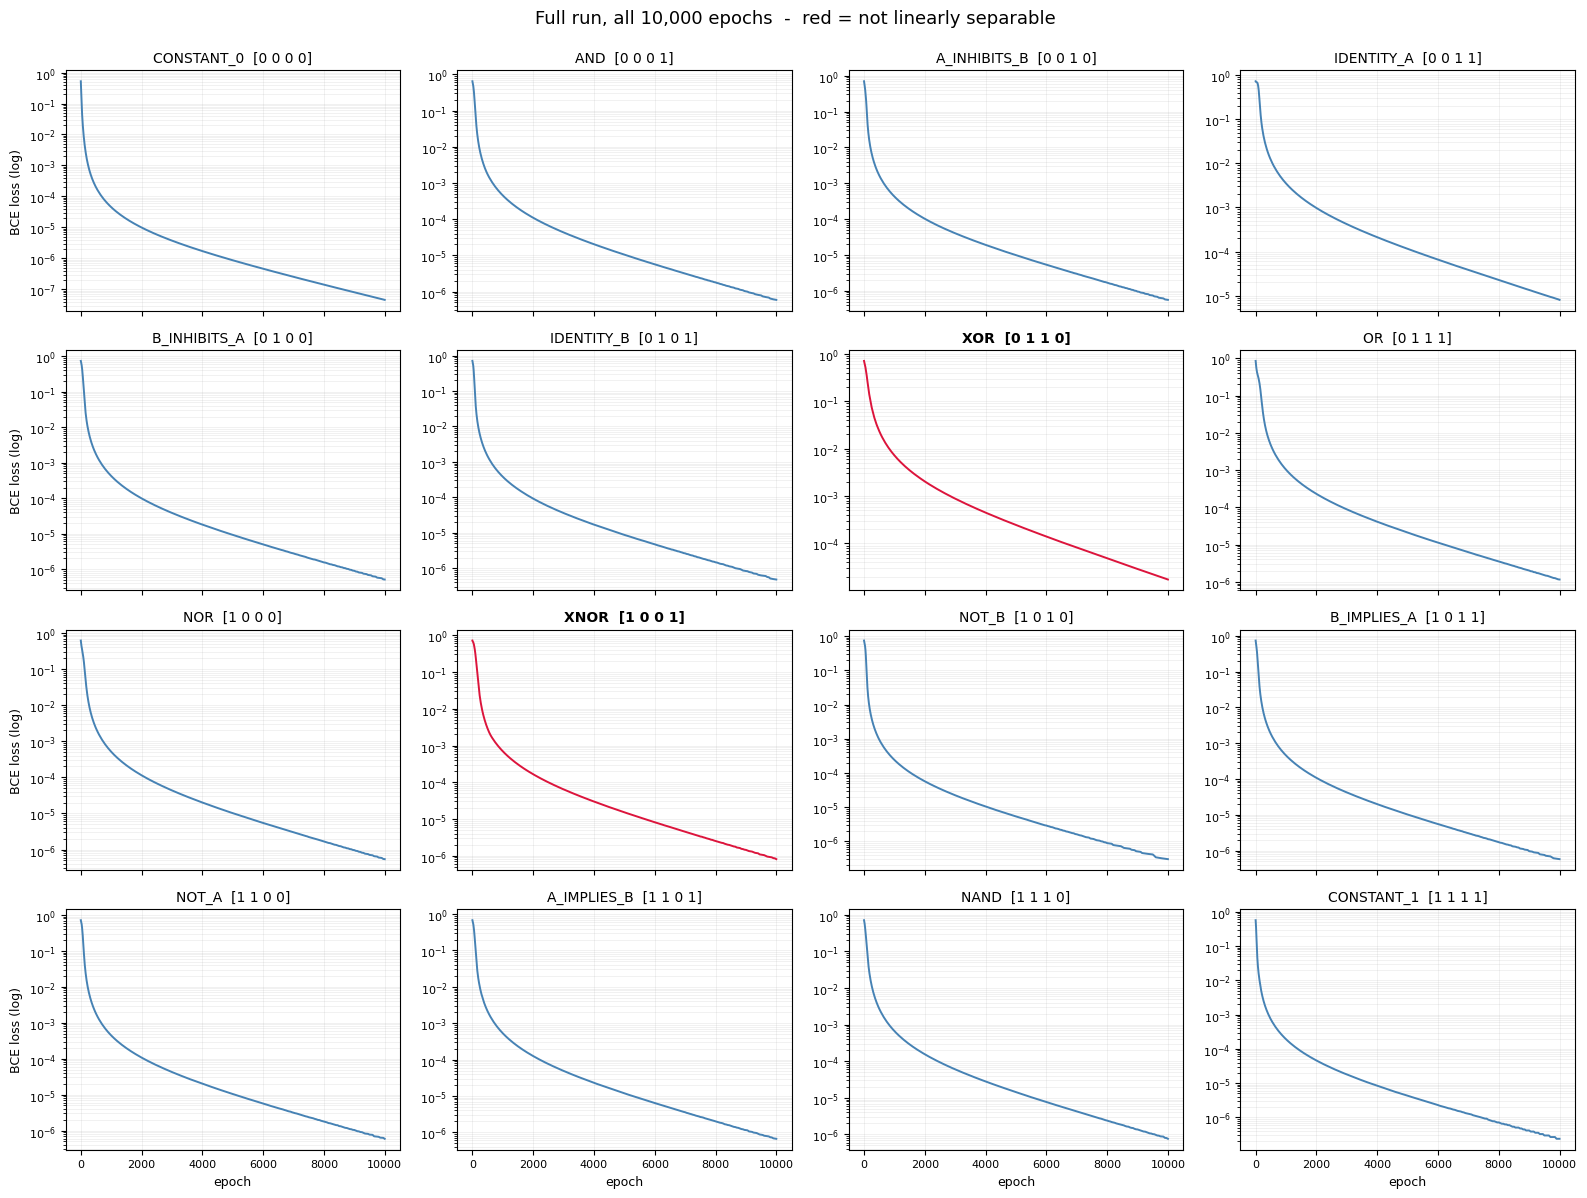

In [8]:
def loss_grid(histories, xlim=None, suptitle=""):
    """4x4 grid of loss curves, one panel per boolean function."""
    fig, axes = plt.subplots(4, 4, figsize=(16, 12), sharex=True)

    for ax, name in zip(axes.flat, histories):
        epochs, losses = zip(*histories[name])
        if xlim is not None:
            kept = [(e, l) for e, l in zip(epochs, losses) if e <= xlim]
            epochs, losses = zip(*kept)

        is_hard = name in NONLINEAR
        ax.plot(epochs, losses,
                color="crimson" if is_hard else "steelblue", linewidth=1.4)
        ax.set_yscale("log")
        bits = " ".join(str(int(v)) for v in TRUTH_TABLES[name].flatten().tolist())
        ax.set_title(f"{name}  [{bits}]", fontsize=10,
                     fontweight="bold" if is_hard else "normal")
        ax.grid(True, which="both", alpha=0.25, linewidth=0.5)
        ax.tick_params(labelsize=8)
        if xlim is not None:
            ax.set_xlim(0, xlim)

    for ax in axes[-1]:
        ax.set_xlabel("epoch", fontsize=9)
    for ax in axes[:, 0]:
        ax.set_ylabel("BCE loss (log)", fontsize=9)

    fig.suptitle(suptitle, fontsize=13, y=0.995)
    fig.tight_layout()
    plt.show()


# Full run: shows where each function ends up.
loss_grid(loss_history,
          suptitle="Full run, all 10,000 epochs  -  red = not linearly separable")

At full scale every panel looks like the same vertical drop, because at width 8 all
16 functions are solved within the first few hundred epochs - 95% of the x-axis is
just the converged tail. The same curves over the first 500 epochs are far more
informative:

The table below is worth reading against the usual claim that the non-separable
functions are the hard ones. `XOR` is indeed the slowest of all 16. But `XNOR` is
**mid-pack, and slower to converge than two linearly separable functions** - `OR`
and `IDENTITY_A` both take longer.

So at width 8, non-separability is not the dominant cost. Eight hidden units are
ample for a 4-row problem, and what little difference remains is nearly lost in the
noise of initialisation. The distinction between `XOR`/`XNOR` and the rest is a
statement about what the architecture *can represent*, and at this width that
constraint simply is not binding. It becomes binding in Part 2, where the hidden
layer is narrowed until it is the only thing that matters.

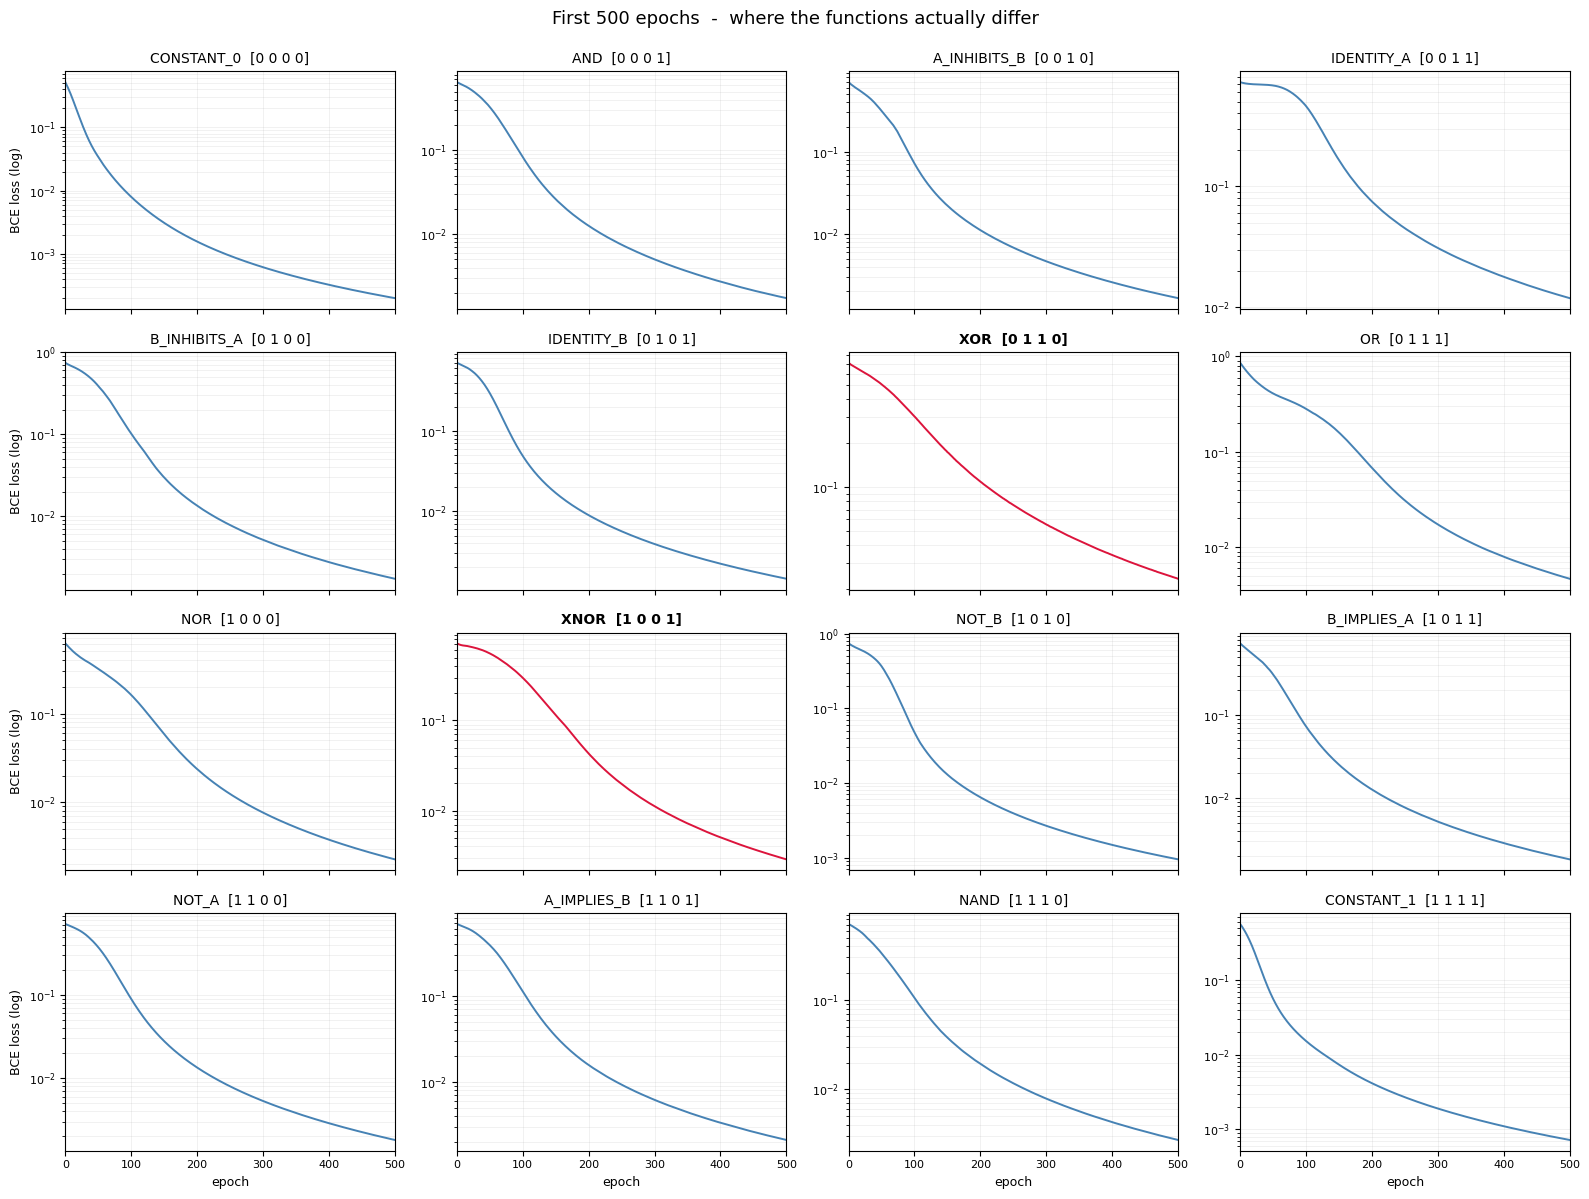

,function,separable,epochs_to_loss<0.05
0,CONSTANT_0,yes,41
1,CONSTANT_1,yes,53
2,NOT_B,yes,99
3,IDENTITY_B,yes,100
4,A_INHIBITS_B,yes,113
5,B_IMPLIES_A,yes,116
6,AND,yes,120
7,NOT_A,yes,122
8,B_INHIBITS_A,yes,128
9,A_IMPLIES_B,yes,132


In [9]:
ZOOM = 500

loss_grid(loss_history, xlim=ZOOM,
          suptitle=f"First {ZOOM} epochs  -  where the functions actually differ")

# Epochs needed to first reach a confidently-correct loss, as a numeric companion
# to the zoomed plot.
THRESHOLD = 0.05
speed = []
for name, history in loss_history.items():
    hit = next((e for e, l in history if l < THRESHOLD), None)
    speed.append({
        "function": name,
        "separable": "no" if name in NONLINEAR else "yes",
        f"epochs_to_loss<{THRESHOLD}": hit if hit is not None else "never",
    })

speed_df = pd.DataFrame(speed).sort_values(
    f"epochs_to_loss<{THRESHOLD}", key=lambda c: pd.to_numeric(c, errors="coerce")
).reset_index(drop=True)
display(speed_df)

---

# Part 2 - How Narrow Can the Hidden Layer Get?

Width 8 solved all 16 functions with room to spare, and Part 1 ended by noting that
representational constraints were not yet binding. This part makes them bind: the
same experiment re-run at **hidden width 4, then 2, then 1**.

Here is the prediction, made before running:

> The 14 linearly separable functions should survive all the way down, since a
> single neuron is a linear classifier with a monotone squashing function - exactly
> what those need. `XOR` and `XNOR` are the ones that should break.

**That prediction is wrong**. It is right about `XOR` and `XNOR`, and badly wrong about the other 14 -
functions as simple as `AND` fail at width 4, where capacity is obviously not the
issue. Sections 2.4 through 2.6 work out what is actually going on.

Where a function breaks still separates the **two kinds of failure** set out at the
top:

- **width 1** - `XOR` cannot be represented at all (proved in 2.5)
- **width 2** - representable in principle, but optimisation may not find it

## 2.1 Refactor training into reusable helpers

In [10]:
def format_bits(t):
    """Render a 4-element 0/1 tensor as '0 1 1 0'."""
    return " ".join(str(int(v)) for v in t.flatten().tolist())


def train_one(model, targets, epochs=EPOCHS, lr=LEARNING_RATE, loss_every=LOSS_EVERY):
    """Full-batch train a single model; returns [(epoch, loss), ...]."""
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = criterion(model(INPUTS), targets)
        loss.backward()
        optimizer.step()
        if record_loss_at(epoch, epochs, loss_every):
            history.append((epoch, loss.item()))
    return history


LIVE_THRESHOLD = 1e-3


def hidden_slope(pre, activation):
    """Local derivative of the hidden nonlinearity at each (input, unit).

    This is the quantity that decides whether gradient reaches the first layer, and
    it generalises "is this unit dead?" across activations. For ReLU it is exactly
    0 or 1, so thresholding it reproduces the earlier "does the unit ever fire?"
    count exactly. For Tanh it is 1 - tanh^2, which is never mathematically zero but
    can underflow once the unit saturates.
    """
    if activation == "tanh":
        return 1.0 - torch.tanh(pre) ** 2
    return (pre > 0).float()


def evaluate_one(model, targets):
    """Round sigmoid outputs to bits and report correctness plus diagnostics."""
    model.eval()
    with torch.no_grad():
        probs = model(INPUTS).flatten()
        slope = hidden_slope(model.net[0](INPUTS), model.activation)
        # Best gradient each unit sees across the 4 inputs; a unit whose best is
        # ~0 is receiving no learning signal at all.
        best_slope = slope.max(dim=0).values
        live_units = int((best_slope > LIVE_THRESHOLD).sum().item())

    target = targets.flatten()
    preds = probs.round()
    return {
        "target": format_bits(target),
        "predicted": format_bits(preds),
        "bits": int((preds == target).sum().item()),
        "margin": float((probs - 0.5).abs().min().item()),
        "live_units": live_units,
        "best_slope": float(best_slope.max()),
    }


def run_experiment(hidden_width, seed=42, epochs=EPOCHS, lr=LEARNING_RATE,
                   activation="relu"):
    """Train and evaluate all 16 functions at one hidden width."""
    torch.manual_seed(seed)   # same seed each width -> comparable initialisation
    models = {name: BooleanNet(hidden_width, activation).to(DEVICE)
              for name in TRUTH_TABLES}

    rows, histories = [], {}
    for name, model in models.items():
        histories[name] = train_one(model, TRUTH_TABLES[name], epochs, lr)
        record = evaluate_one(model, TRUTH_TABLES[name])
        record.update(
            function=name,
            hidden_width=hidden_width,
            activation=activation,
            final_loss=histories[name][-1][1],
            result="PASS" if record["bits"] == 4 else "FAIL",
        )
        rows.append(record)

    columns = ["function", "hidden_width", "activation", "target", "predicted",
               "bits", "final_loss", "margin", "live_units", "best_slope", "result"]
    return pd.DataFrame(rows)[columns], histories


print("helpers defined: format_bits, train_one, evaluate_one, run_experiment")

helpers defined: format_bits, train_one, evaluate_one, run_experiment


## 2.2 Run the sweep

Width 8 is re-run here through the refactored code path rather than reusing the
Part 1 models. That costs a couple of extra minutes but makes the comparison
strictly apples-to-apples, and it double-checks that the refactor reproduces the
earlier 16/16 result.

Every width starts from `manual_seed(42)`, so differences across widths come from
capacity, not from a different draw of random numbers.

In [11]:
WIDTHS = [8, 4, 2, 1]

sweep_results, sweep_histories = {}, {}
sweep_start = time.perf_counter()

for width in WIDTHS:
    t0 = time.perf_counter()
    df, histories = run_experiment(width)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    sweep_results[width] = df
    sweep_histories[width] = histories

    passed = int((df["result"] == "PASS").sum())
    failed = df.loc[df["result"] == "FAIL", "function"].tolist()
    print(f"width {width:>2}: {passed:>2}/16 passed  ({time.perf_counter() - t0:5.1f}s)"
          + (f"   failed: {', '.join(failed)}" if failed else ""))

all_results = pd.concat(sweep_results.values(), ignore_index=True)
print(f"\nsweep complete in {time.perf_counter() - sweep_start:.1f}s on {DEVICE}")

width  8: 16/16 passed  (179.3s)


width  4: 14/16 passed  (174.2s)   failed: AND, XOR


width  2: 12/16 passed  (175.6s)   failed: IDENTITY_B, XOR, B_IMPLIES_A, A_IMPLIES_B


width  1: 10/16 passed  (170.8s)   failed: B_INHIBITS_A, IDENTITY_B, XOR, XNOR, NOT_B, A_IMPLIES_B

sweep complete in 699.9s on cuda


## 2.3 Pass/fail matrix across widths

In [12]:
ORDERED = [name for name, _ in FUNCTION_DEFS]

matrix = (
    all_results.pivot(index="function", columns="hidden_width", values="result")
    .loc[ORDERED, WIDTHS]
)
matrix.columns = [f"width {w}" for w in WIDTHS]
matrix.insert(0, "separable", ["no" if n in NONLINEAR else "yes" for n in ORDERED])
display(matrix)

summary = pd.DataFrame({
    "passed": [int((sweep_results[w]["result"] == "PASS").sum()) for w in WIDTHS],
    # Linear(2,w) has 2w weights + w biases; Linear(w,1) has w weights + 1 bias.
    "params": [4 * w + 1 for w in WIDTHS],
    "dead_layers": [int((sweep_results[w]["live_units"] == 0).sum()) for w in WIDTHS],
    "worst_loss": [sweep_results[w]["final_loss"].max() for w in WIDTHS],
}, index=[f"width {w}" for w in WIDTHS])
summary["passed"] = summary["passed"].astype(str) + "/16"
summary["worst_loss"] = summary["worst_loss"].map(lambda v: f"{v:.4f}")
display(summary)

print("`dead_layers` counts models whose every hidden ReLU is off for all 4 inputs.")

,separable,width 8,width 4,width 2,width 1
function,,,,,
CONSTANT_0,yes,PASS,PASS,PASS,PASS
AND,yes,PASS,FAIL,PASS,PASS
A_INHIBITS_B,yes,PASS,PASS,PASS,PASS
IDENTITY_A,yes,PASS,PASS,PASS,PASS
B_INHIBITS_A,yes,PASS,PASS,PASS,FAIL
IDENTITY_B,yes,PASS,PASS,FAIL,FAIL
XOR,no,PASS,FAIL,FAIL,FAIL
OR,yes,PASS,PASS,PASS,PASS
NOR,yes,PASS,PASS,PASS,PASS


,passed,params,dead_layers,worst_loss
width 8,16/16,33,0,0.0000
width 4,14/16,17,1,0.5623
width 2,12/16,9,3,0.6931
width 1,10/16,5,5,0.6931


`dead_layers` counts models whose every hidden ReLU is off for all 4 inputs.


## 2.4 Reading the failures from the loss value alone

Failures here do not land on arbitrary loss values. They land on a small set of
**exact constants**, and each constant identifies a specific failure mode. Three
of them show up in this sweep.

**1. The dead-layer floor.** If every hidden ReLU is off for all four inputs, the
gradient into the hidden layer is zero and the network is frozen as a constant
predictor $\sigma(b_2)$. The best constant for a target with $k$ ones out of 4 is
$p = k/4$, giving a BCE equal to the **Shannon entropy of the target bits** (in nats):

$$\mathcal{L}_{\text{dead}} = H(k/4) = -\tfrac{k}{4}\ln\tfrac{k}{4} - \left(1 - \tfrac{k}{4}\right)\ln\left(1 - \tfrac{k}{4}\right)$$

- $k = 2$ (balanced, e.g. `XOR`, `IDENTITY_B`): $\ln 2 \approx 0.693147$
- $k = 1$ or $3$ (e.g. `AND`, `A_IMPLIES_B`): $\approx 0.562335$
- $k = 0$ or $4$ (the two constant functions): $0$ - which is why `CONSTANT_0` and
  `CONSTANT_1` still **pass** with a completely dead hidden layer. The bias alone
  is a correct solution for them.

**2. The monotone-collapse floor for XOR.** A model that is monotone in a single
linear projection - which is *any* width-1 net, and any wider net that has
functionally collapsed - can still get 3 of the 4 `XOR` rows right. Optimising the
one it must sacrifice gives, at $q = 1/3$:

$$\mathcal{L}_{\min} = \tfrac{1}{4}\left(3\ln 3 - 2\ln 2\right) \approx 0.477386$$

This is **below** the $\ln 2$ dead floor: a live width-1 net genuinely beats chance
on `XOR`, it just cannot reach zero.

**3. Success**, at a loss of order $10^{-5}$ or smaller.

So the final loss is a fingerprint. The cell below classifies every failure by
matching against these constants.

In [13]:
def dead_layer_floor(targets):
    """BCE of the best constant predictor = entropy (nats) of the target bits."""
    p = float(targets.mean().item())
    if p in (0.0, 1.0):
        return 0.0
    return -(p * np.log(p) + (1 - p) * np.log(1 - p))


MONOTONE_XOR_FLOOR = (3 * np.log(3) - 2 * np.log(2)) / 4

print(f"monotone-collapse floor for XOR/XNOR : {MONOTONE_XOR_FLOOR:.6f}")
print(f"dead floor, balanced target (k=2)    : {np.log(2):.6f}")
print(f"dead floor, skewed target  (k=1,3)   : {dead_layer_floor(TRUTH_TABLES['AND']):.6f}")
print(f"dead floor, constant target (k=0,4)  : {dead_layer_floor(TRUTH_TABLES['CONSTANT_0']):.6f}\n")


def diagnose(row):
    floor = dead_layer_floor(TRUTH_TABLES[row.function])
    if row.live_units == 0:
        return "dead layer (all ReLUs off)"
    if abs(row.final_loss - MONOTONE_XOR_FLOOR) < 1e-3:
        return "monotone collapse (3 of 4 rows)"
    if abs(row.final_loss - floor) < 1e-3:
        return "collapsed to constant predictor"
    return "other / partial fit"


failures = all_results[all_results["result"] == "FAIL"].copy()
if len(failures):
    failures["diagnosis"] = failures.apply(diagnose, axis=1)
    failures["dead_floor"] = failures["function"].map(
        lambda n: round(dead_layer_floor(TRUTH_TABLES[n]), 6))
    display(failures[["hidden_width", "function", "target", "predicted", "bits",
                      "final_loss", "live_units", "dead_floor", "diagnosis"]]
            .sort_values(["hidden_width", "function"], ascending=[False, True])
            .reset_index(drop=True))
    print("\nfailure modes by count:")
    display(failures["diagnosis"].value_counts().to_frame("count"))
else:
    print("no failures at any width")

monotone-collapse floor for XOR/XNOR : 0.477386
dead floor, balanced target (k=2)    : 0.693147
dead floor, skewed target  (k=1,3)   : 0.562335
dead floor, constant target (k=0,4)  : 0.000000



,hidden_width,function,target,predicted,bits,final_loss,live_units,dead_floor,diagnosis
0,4,AND,0 0 0 1,0 0 0 0,3,0.562335,0,0.562335,dead layer (all ReLUs off)
1,4,XOR,0 1 1 0,0 1 1 1,3,0.477386,3,0.693147,monotone collapse (3 of 4 rows)
2,2,A_IMPLIES_B,1 1 0 1,1 1 1 1,3,0.562335,0,0.562335,dead layer (all ReLUs off)
3,2,B_IMPLIES_A,1 0 1 1,1 1 1 1,3,0.562335,0,0.562335,dead layer (all ReLUs off)
4,2,IDENTITY_B,0 1 0 1,0 0 0 0,2,0.693147,0,0.693147,dead layer (all ReLUs off)
5,2,XOR,0 1 1 0,0 0 0 0,2,0.693147,1,0.693147,collapsed to constant predictor
6,1,A_IMPLIES_B,1 1 0 1,1 1 1 1,3,0.562335,0,0.562335,dead layer (all ReLUs off)
7,1,B_INHIBITS_A,0 1 0 0,0 0 0 0,3,0.562335,0,0.562335,dead layer (all ReLUs off)
8,1,IDENTITY_B,0 1 0 1,0 0 0 0,2,0.693147,0,0.693147,dead layer (all ReLUs off)
9,1,NOT_B,1 0 1 0,0 0 0 0,2,0.693147,0,0.693147,dead layer (all ReLUs off)



failure modes by count:


,count
diagnosis,
dead layer (all ReLUs off),8
monotone collapse (3 of 4 rows),2
collapsed to constant predictor,2


## 2.5 Why width 1 *cannot* do XOR, as opposed to merely not doing it

Most of the failures above are optimisation accidents. Two of them are not, and
that case can be settled with a proof.

With a single hidden unit the whole network is

$$f(a,b) = \sigma\big(w_2 \cdot \mathrm{relu}(s) + b_2\big), \qquad s = w_a a + w_b b + b_1$$

Two properties of this expression do all the work.

**$f$ is monotone in $s$.** `relu` is non-decreasing, $\sigma$ is increasing, adding
$b_2$ is a shift, and scaling by $w_2$ is monotone in one direction or the other. So
$f$ is a monotone function of the single scalar $s$.

**$s$ is affine in $(a, b)$.** *Affine* means linear plus a constant offset: the
$w_a a + w_b b$ part is linear, and the bias $b_1$ shifts it. A strictly linear map
must send the origin to zero, and dropping that requirement is exactly what affine
does. Every `nn.Linear` layer is affine in this sense whenever `bias=True`, which is
the default.

Affine maps preserve midpoints. The four inputs form a
unit square, and its two diagonals share the same midpoint, $(0.5, 0.5)$. The average
of $s$ over the ends of one diagonal is therefore $s(0.5, 0.5)$ - and so is the
average over the ends of the other. Equal averages mean equal sums:

$$s(0,0) + s(1,1) = w_a + w_b + 2b_1 = s(0,1) + s(1,0)$$

The bias lands on both sides as $2b_1$ and cancels.

`XOR` requires $f$ **low** at $(0,0)$ and $(1,1)$ and **high** at $(0,1)$ and
$(1,0)$. If $f$ increases with $s$, that forces
$\min(s_{01}, s_{10}) > \max(s_{00}, s_{11})$ and hence
$s_{01} + s_{10} > s_{00} + s_{11}$ - contradicting the equality. If $f$ decreases
with $s$, the same argument runs with the inequality reversed. Either way,
**contradiction**.

No width-1 network can represent `XOR` or `XNOR`. The argument used nothing about
`relu` beyond monotonicity, so it holds for sigmoid or tanh units too, and it says
nothing about Adam, the learning rate, the seed, or the epoch budget. **Training
longer cannot fix this one.** The best such a model can do is the 0.477386 floor
derived above - three rows right, one permanently wrong.

The assertions below check what the proof guarantees, not just what this run
produced.

In [14]:
w1 = sweep_results[1].set_index("function")

# 1. Provable: one hidden unit cannot represent XOR or XNOR.
for name in NONLINEAR:
    assert w1.loc[name, "result"] == "FAIL", (
        f"{name} reported PASS at width 1, which is representationally impossible "
        f"- suspect a bug in the evaluation path"
    )

# 2. Provable: it also cannot beat the monotone-collapse floor.
assert w1.loc["XOR", "final_loss"] >= MONOTONE_XOR_FLOOR - 1e-4, (
    f"width-1 XOR loss {w1.loc['XOR', 'final_loss']:.6f} is below the proven "
    f"optimum {MONOTONE_XOR_FLOOR:.6f}"
)

# 3. Width 8 must still solve everything, matching Part 1.
w8_passed = int((sweep_results[8]["result"] == "PASS").sum())
assert w8_passed == 16, f"width 8 regressed: {w8_passed}/16"

# 4. A dead hidden layer must sit exactly on the entropy of its target bits.
dead = all_results[all_results["live_units"] == 0]
for _, r in dead.iterrows():
    floor = dead_layer_floor(TRUTH_TABLES[r.function])
    assert abs(r.final_loss - floor) < 2e-3, (
        f"{r.function} at width {r.hidden_width} has a dead hidden layer but loss "
        f"{r.final_loss:.6f} != entropy floor {floor:.6f}"
    )

# 5. The constant functions are solvable by the output bias alone, so they must
#    pass at every width even when the hidden layer is dead.
for width in WIDTHS:
    by_name = sweep_results[width].set_index("function")
    for name in ("CONSTANT_0", "CONSTANT_1"):
        assert by_name.loc[name, "result"] == "PASS", (
            f"{name} failed at width {width}, but the output bias alone suffices"
        )

# 6. Structural sanity.
assert len(all_results) == 16 * len(WIDTHS)

print("ALL ASSERTIONS PASSED\n")
for width in WIDTHS:
    df = sweep_results[width]
    passed = int((df["result"] == "PASS").sum())
    failed = df.loc[df["result"] == "FAIL", "function"].tolist()
    print(f"  width {width:>2}: {passed:>2}/16"
          + (f"   failed: {', '.join(failed)}" if failed else "   (all pass)"))
print(f"\n  {len(dead)} of {len(all_results)} models finished with a fully dead "
      f"hidden layer, each pinned exactly to its target-entropy floor.")

ALL ASSERTIONS PASSED

  width  8: 16/16   (all pass)
  width  4: 14/16   failed: AND, XOR
  width  2: 12/16   failed: IDENTITY_B, XOR, B_IMPLIES_A, A_IMPLIES_B
  width  1: 10/16   failed: B_INHIBITS_A, IDENTITY_B, XOR, XNOR, NOT_B, A_IMPLIES_B

  9 of 64 models finished with a fully dead hidden layer, each pinned exactly to its target-entropy floor.


## 2.6 Capacity or bad luck? Retry every failure with new seeds

The proof covers `XOR` and `XNOR` at width 1. Every other failure above is
*claimed* to be an optimisation accident - but that claim is untested, because each
was trained exactly once from `seed=42`.

The test is direct: take every (width, function) pair that failed and retrain it
from several different seeds. A pair that succeeds under some seed was never a
capacity problem. A pair that fails under every seed is either genuinely
unrepresentable or sits in a basin the optimiser reliably falls into.

In [15]:
RETRY_SEEDS = [0, 1, 2, 3]

recovery = []
for width in WIDTHS:
    failed = sweep_results[width].loc[
        sweep_results[width]["result"] == "FAIL", "function"].tolist()
    for name in failed:
        passes, live_counts = 0, []
        for seed in RETRY_SEEDS:
            torch.manual_seed(seed)
            model = BooleanNet(width).to(DEVICE)
            train_one(model, TRUTH_TABLES[name])
            record = evaluate_one(model, TRUTH_TABLES[name])
            passes += record["bits"] == 4
            live_counts.append(record["live_units"])
        recovery.append({
            "hidden_width": width,
            "function": name,
            "separable": "no" if name in NONLINEAR else "yes",
            "seeds_passed": f"{passes}/{len(RETRY_SEEDS)}",
            "recovered": passes > 0,
            "mean_live_units": round(float(np.mean(live_counts)), 2),
        })

recovery_df = pd.DataFrame(recovery)
display(recovery_df.sort_values(["hidden_width", "function"],
                                ascending=[False, True]).reset_index(drop=True))

# Provable: no seed can rescue XOR or XNOR at width 1.
stuck = recovery_df[(recovery_df.hidden_width == 1)
                    & (recovery_df.function.isin(NONLINEAR))]
assert not stuck["recovered"].any(), (
    "a width-1 net passed XOR/XNOR under some seed - representationally impossible"
)

recovered = recovery_df[recovery_df["recovered"]]
never = recovery_df[~recovery_df["recovered"]]

print(f"\nrecovered under at least one seed : {len(recovered)}/{len(recovery_df)}")
print(f"failed under every seed tried     : {len(never)}/{len(recovery_df)}")
if len(recovered):
    print("\n  optimisation accidents (a different init fixes them):")
    for _, r in recovered.iterrows():
        print(f"    width {r.hidden_width}  {r.function}  ({r.seeds_passed} seeds)")
if len(never):
    print("\n  never recovered:")
    for _, r in never.iterrows():
        why = ("proved impossible" if r.hidden_width == 1 and r.function in NONLINEAR
               else "representable, but not reached by this recipe")
        print(f"    width {r.hidden_width}  {r.function}  -  {why}")

,hidden_width,function,separable,seeds_passed,recovered,mean_live_units
0,4,AND,yes,4/4,True,3.00
1,4,XOR,no,4/4,True,3.00
2,2,A_IMPLIES_B,yes,3/4,True,1.25
3,2,B_IMPLIES_A,yes,3/4,True,1.25
4,2,IDENTITY_B,yes,3/4,True,1.00
5,2,XOR,no,0/4,False,1.00
6,1,A_IMPLIES_B,yes,1/4,True,0.25
7,1,B_INHIBITS_A,yes,1/4,True,0.25
8,1,IDENTITY_B,yes,1/4,True,0.25
9,1,NOT_B,yes,2/4,True,0.50



recovered under at least one seed : 9/12
failed under every seed tried     : 3/12

  optimisation accidents (a different init fixes them):
    width 4  AND  (4/4 seeds)
    width 4  XOR  (4/4 seeds)
    width 2  IDENTITY_B  (3/4 seeds)
    width 2  B_IMPLIES_A  (3/4 seeds)
    width 2  A_IMPLIES_B  (3/4 seeds)
    width 1  B_INHIBITS_A  (1/4 seeds)
    width 1  IDENTITY_B  (1/4 seeds)
    width 1  NOT_B  (2/4 seeds)
    width 1  A_IMPLIES_B  (1/4 seeds)

  never recovered:
    width 2  XOR  -  representable, but not reached by this recipe
    width 1  XOR  -  proved impossible
    width 1  XNOR  -  proved impossible


## 2.7 Findings

The summary below is computed from the results above rather than written by hand,
so it cannot drift out of step with what actually ran.

In [16]:
print("=" * 72)
print("WIDTH SWEEP - FINDINGS".center(72))
print("=" * 72)

for width in WIDTHS:
    df = sweep_results[width]
    passed = int((df["result"] == "PASS").sum())
    dead_n = int((df["live_units"] == 0).sum())
    bar = "#" * passed + "." * (16 - passed)
    print(f"\n  width {width:>2} ({4 * width + 1:>2} params)  [{bar}]  {passed:>2}/16")
    if passed < 16:
        for _, r in df[df["result"] == "FAIL"].iterrows():
            tag = "PROVED IMPOSSIBLE" if (width == 1 and r.function in NONLINEAR) \
                  else ("dead layer" if r.live_units == 0 else "bad basin")
            print(f"       - {r.function:<14} loss={r.final_loss:.4f}  "
                  f"live={r.live_units}/{width}  [{tag}]")
    print(f"       {dead_n} model(s) with a fully dead hidden layer")

nonlinear_ok = [w for w in WIDTHS
                if all(sweep_results[w].set_index("function").loc[n, "result"] == "PASS"
                       for n in NONLINEAR)]
print("\n" + "-" * 72)
print(f"  XOR and XNOR both solved at widths : "
      f"{', '.join(map(str, nonlinear_ok)) if nonlinear_ok else 'none'}")
print(f"  narrowest width solving all 16     : "
      f"{min([w for w in WIDTHS if (sweep_results[w]['result'] == 'PASS').all()], default='none')}")
print(f"  total dead-layer collapses         : "
      f"{int((all_results['live_units'] == 0).sum())} / {len(all_results)} models")
print(f"  failures rescued by a new seed     : "
      f"{int(recovery_df['recovered'].sum())} / {len(recovery_df)}")
print("-" * 72)

                         WIDTH SWEEP - FINDINGS                         

  width  8 (33 params)  [################]  16/16
       0 model(s) with a fully dead hidden layer

  width  4 (17 params)  [##############..]  14/16
       - AND            loss=0.5623  live=0/4  [dead layer]
       - XOR            loss=0.4774  live=3/4  [bad basin]
       1 model(s) with a fully dead hidden layer

  width  2 ( 9 params)  [############....]  12/16
       - IDENTITY_B     loss=0.6931  live=0/2  [dead layer]
       - XOR            loss=0.6931  live=1/2  [bad basin]
       - B_IMPLIES_A    loss=0.5623  live=0/2  [dead layer]
       - A_IMPLIES_B    loss=0.5623  live=0/2  [dead layer]
       3 model(s) with a fully dead hidden layer

  width  1 ( 5 params)  [##########......]  10/16
       - B_INHIBITS_A   loss=0.5623  live=0/1  [dead layer]
       - IDENTITY_B     loss=0.6931  live=0/1  [dead layer]
       - XOR            loss=0.4774  live=1/1  [PROVED IMPOSSIBLE]
       - XNOR           loss=0.

## 2.8 Part 2 conclusions

Narrowing the hidden layer did lower accuracy, but capacity is rarely what caused
the drop.

- **Dying ReLU units account for most of it.** In 8 of the 12 failures the whole
  hidden layer had switched off, leaving the network frozen as a constant predictor
  sitting on the entropy of its target bits. A ReLU that is off for all four inputs
  receives no gradient, and with only four training points and no stochasticity
  there is nothing left to push it back into its active range. A narrow layer is more
  exposed because losing one unit costs a larger fraction of it, and at width 1 or 2
  losing one unit is fatal. This is how `AND`, which is linearly separable, ends up
  failing at width 4.

- **`XOR` and `XNOR` at width 1 are the only real capacity limits**, and we have a
  proof for them: a single hidden unit makes the network a monotone function of one
  linear projection, and those two targets cannot be written that way. The retry cell
  finds no seed that rescues them, which is what the proof predicts.

- **"Narrowest width solving all 16: 8" is a statement about seed 42.** Width 4
  failed `AND` and `XOR` on that seed, but the retry in 2.6 recovers both on 4 of 4
  other seeds. Width 4 can represent all 16 functions and can be trained to them; it
  drew a bad initialisation once.

- **Width 2 can represent `XOR` but did not learn it here.** The closed form
  $\mathrm{XOR}(a,b) = \mathrm{relu}(a+b) - 2\,\mathrm{relu}(a+b-1)$ uses exactly two
  hidden units, so a solution is there to be found. Training did not find it on any
  seed tried at this learning rate and budget. With two units, losing one leaves the
  width-1 case that the proof rules out, so there is no margin for error. Part 4
  searches beyond this recipe and does find it - including at this same learning rate,
  a few seeds further on - so read this as a result about the recipe rather than about
  width 2.

The diagnostic carries over to larger problems. If the loss settles on a number you
could have computed in advance - the entropy of the labels - the model is dead rather
than converging slowly, and more epochs will not change it. If the loss settles at
different heights on different seeds, the problem is optimisation, and a different
initialisation, learning rate, or activation may fix it. If no seed ever beats the
same floor, look at the architecture. Part 2 has an example of each, and the final
loss value was enough to sort them.

---

# Part 3 - Looking at the Loss Surface

Part 2 identified dead units from two numbers: a live-unit count of zero and a final
loss sitting on the target's entropy. Both are indirect. This part plots the loss
surface itself, so the dead region can be seen.

The prediction is specific. If a dead hidden layer produces a constant output, the
loss must be exactly flat across the whole dead region, because no weight in the
first layer changes the output there. A flat region has zero gradient, so an
optimiser that lands in one has nothing to follow back out.

## 3.1 A batched loss-surface evaluator

In [17]:
def flatten_model(model):
    """Trained parameters as one flat vector: [W1, b1, W2, b2]."""
    layers = model.net
    return torch.cat([
        layers[0].weight.detach().flatten(),
        layers[0].bias.detach().flatten(),
        layers[2].weight.detach().flatten(),
        layers[2].bias.detach().flatten(),
    ])


def unpack_theta(theta, width):
    """Split a batch of flat vectors (G, 4w+1) back into layer tensors."""
    g, i = theta.shape[0], 0
    W1 = theta[:, i:i + 2 * width].reshape(g, width, 2); i += 2 * width
    b1 = theta[:, i:i + width];                          i += width
    W2 = theta[:, i:i + width];                          i += width
    b2 = theta[:, i:i + 1]
    return W1, b1, W2, b2


def landscape(theta, width, targets, chunk=20000, activation="relu"):
    """Evaluate BCE loss and the dead-layer mask for many parameter vectors at once.

    Uses the with-logits form of BCE: mathematically identical to the Sigmoid +
    BCELoss used in training, but it does not overflow far from the optimum, where
    the sigmoid saturates and log(0) would appear.

    "Dead" means no gradient reaches the first layer: for ReLU that is every unit
    clamped off, for Tanh it is every unit saturated hard enough that 1 - tanh^2
    falls below LIVE_THRESHOLD.
    """
    y = targets.flatten()
    losses, deads = [], []

    for start in range(0, theta.shape[0], chunk):
        W1, b1, W2, b2 = unpack_theta(theta[start:start + chunk], width)
        pre = torch.einsum("gwi,ni->gnw", W1, INPUTS) + b1[:, None, :]
        hidden = torch.tanh(pre) if activation == "tanh" else torch.relu(pre)
        logits = torch.einsum("gnw,gw->gn", hidden, W2) + b2

        losses.append(nn.functional.binary_cross_entropy_with_logits(
            logits, y.expand_as(logits), reduction="none").mean(dim=1))
        slope = hidden_slope(pre, activation)
        deads.append((slope <= LIVE_THRESHOLD).flatten(1).all(dim=1))

    return torch.cat(losses), torch.cat(deads)


def coordinate_grid(theta0, idx_x, idx_y, span, n=141):
    """Vary two coordinates of theta0 over a square grid, holding the rest fixed."""
    xs = torch.linspace(float(theta0[idx_x]) - span, float(theta0[idx_x]) + span, n,
                        device=DEVICE)
    ys = torch.linspace(float(theta0[idx_y]) - span, float(theta0[idx_y]) + span, n,
                        device=DEVICE)
    XX, YY = torch.meshgrid(xs, ys, indexing="xy")

    theta = theta0.repeat(n * n, 1)
    theta[:, idx_x] = XX.reshape(-1)
    theta[:, idx_y] = YY.reshape(-1)
    return theta, XX, YY


def surface_3d(ax, XX, YY, Z, dead, title, zlabel="BCE loss", clip_q=None):
    """3D surface with the dead-layer region shaded on the floor.

    Far from the optimum the sigmoid saturates and BCE grows without bound, so a
    raw surface is dominated by a cone that flattens everything worth seeing.
    `clip_q` caps the height at a quantile of the grid to restore the detail.
    """
    if clip_q is not None:
        cap = float(torch.quantile(Z.flatten().float(), clip_q))
        Z = Z.clamp(max=cap)
        zlabel += " (clipped)"

    Xn, Yn, Zn = XX.cpu().numpy(), YY.cpu().numpy(), Z.cpu().numpy()
    Dn = dead.cpu().numpy()

    # Paint the dead region red on the surface itself - shading it only on the floor
    # leaves you guessing which part of the surface is the plateau.
    norm = plt.Normalize(float(Zn.min()), float(Zn.max()))
    facecolors = plt.cm.viridis(norm(Zn))
    facecolors[Dn] = np.array([0.84, 0.15, 0.16, 1.0])

    ax.plot_surface(Xn, Yn, Zn, facecolors=facecolors, linewidth=0,
                    antialiased=True, shade=False, rstride=1, cstride=1)

    floor = float(Zn.min()) - 0.12 * (float(Zn.max()) - float(Zn.min()) + 1e-9)
    if bool(dead.any()):
        ax.contourf(Xn, Yn, Dn.astype(float), levels=[0.5, 1.5],
                    colors=["#d62728"], alpha=0.3, zdir="z", offset=floor)
    ax.set_zlim(floor, float(Zn.max()))
    ax.set_title(title, fontsize=11)
    ax.set_zlabel(zlabel, fontsize=8)
    ax.tick_params(labelsize=7)
    return ax


print("landscape helpers ready")

landscape helpers ready


## 3.2 The dead region is an exactly flat plateau

A width-1 network has 5 parameters, so sweeping the two input weights $w_a, w_b$
while holding $b_1, w_2, b_2$ at their trained values gives a genuine 2D slice of a
5D space, with no projection or approximation involved.

The region where the hidden unit is off for all four inputs is painted red on the
surface itself, with a matching patch on the floor. `XOR` is shown next to `AND` for
contrast: same architecture, same slice, one with a reachable solution and one
without.

The height of the plateau needs a note. In Part 2 the dead models sat on the entropy
of their labels, because the output bias had been trained to the best constant. Here
the output bias is frozen at the value a live solution converged to, so a dead unit
gives a confidently wrong answer on at least one row and the plateau sits higher. The
height moves with the frozen bias; the flatness is the part to read.

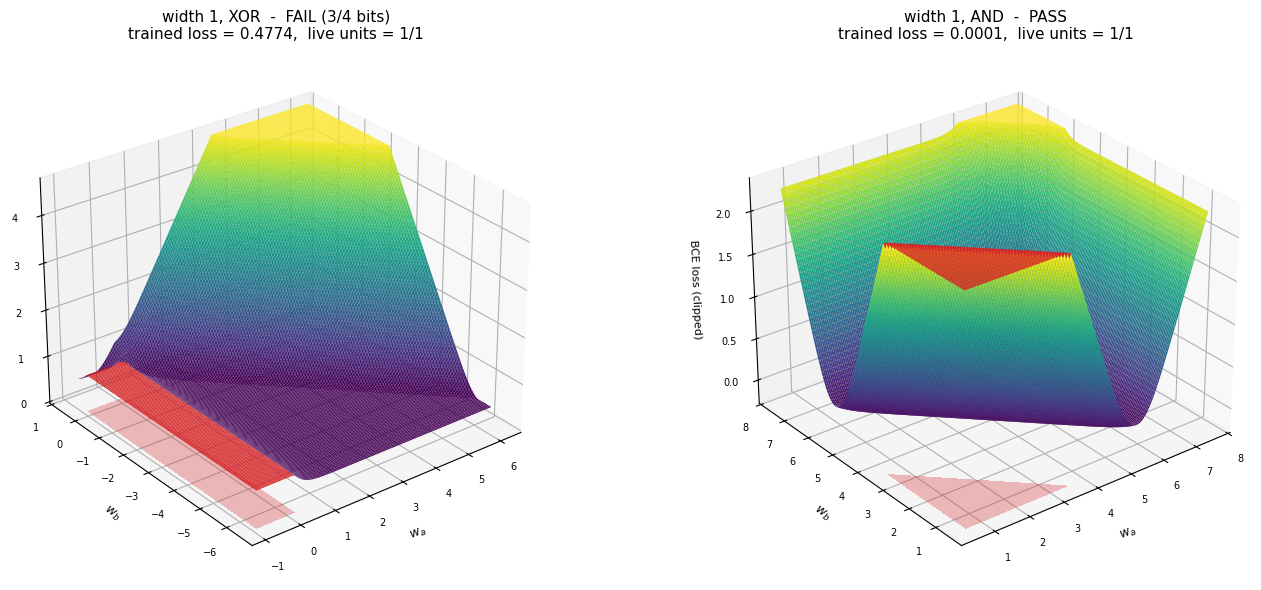

XOR  dead region:  14.7% of the slice, loss range across it = 0.00e+00
AND  dead region:   8.9% of the slice, loss range across it = 0.00e+00

red floor patch = hidden unit off for all 4 inputs
a loss range of ~0 across that region is the plateau, measured rather than asserted


In [18]:
# Seed 5 is chosen deliberately: at width 1 it leaves the hidden unit ALIVE for both
# AND and XOR. That separates the two failure causes - any difference between the
# panels below is about representational capacity, not about a dead ReLU.
LANDSCAPE_SEED = 5

landscape_models = {}
for label, width, fname in [("XOR", 1, "XOR"), ("AND", 1, "AND")]:
    torch.manual_seed(LANDSCAPE_SEED)
    model = BooleanNet(width).to(DEVICE)
    train_one(model, TRUTH_TABLES[fname])
    landscape_models[label] = (model, width, fname)

notes = []
fig = plt.figure(figsize=(15, 6))
for panel, label in enumerate(["XOR", "AND"], start=1):
    model, width, fname = landscape_models[label]
    targets = TRUTH_TABLES[fname]
    theta0 = flatten_model(model)

    theta, XX, YY = coordinate_grid(theta0, 0, 1, span=3.5)
    loss, dead = landscape(theta, width, targets)
    Z, D = loss.reshape(XX.shape), dead.reshape(XX.shape)

    here, _ = landscape(theta0[None, :], width, targets)
    record = evaluate_one(model, targets)
    verdict = "PASS" if record["bits"] == 4 else f"FAIL ({record['bits']}/4 bits)"

    ax = fig.add_subplot(1, 2, panel, projection="3d")
    surface_3d(ax, XX, YY, Z, D, clip_q=0.9,
               title=f"width 1, {label}  -  {verdict}\n"
                     f"trained loss = {float(here[0]):.4f},  "
                     f"live units = {record['live_units']}/{width}")
    ax.set_xlabel("$w_a$", fontsize=9)
    ax.set_ylabel("$w_b$", fontsize=9)
    ax.view_init(elev=28, azim=-128)

    flat = Z[D]
    if flat.numel():
        notes.append(
            f"{label:<4} dead region: {D.float().mean() * 100:5.1f}% of the slice, "
            f"loss range across it = {float(flat.max() - flat.min()):.2e}")

plt.tight_layout()
plt.show()

for note in notes:
    print(note)
print("\nred floor patch = hidden unit off for all 4 inputs")
print("a loss range of ~0 across that region is the plateau, measured rather than asserted")

## 3.3 How large is the dead region, and why does narrowing make it worse?

The previous slice fixed the bias. Whether a unit is dead depends on
$(w_a, w_b, b_1)$ together, and the condition is exact: the unit fires on input
$(a, b)$ when $w_a a + w_b b + b_1 > 0$.

Nothing is trained below. This is the geometry of the ReLU, counting how many of the
4 inputs a single unit responds to. The darkest region is where it responds to none
of them, and a unit that lands there stays there, because a unit that is off for
every input in the dataset receives zero gradient.

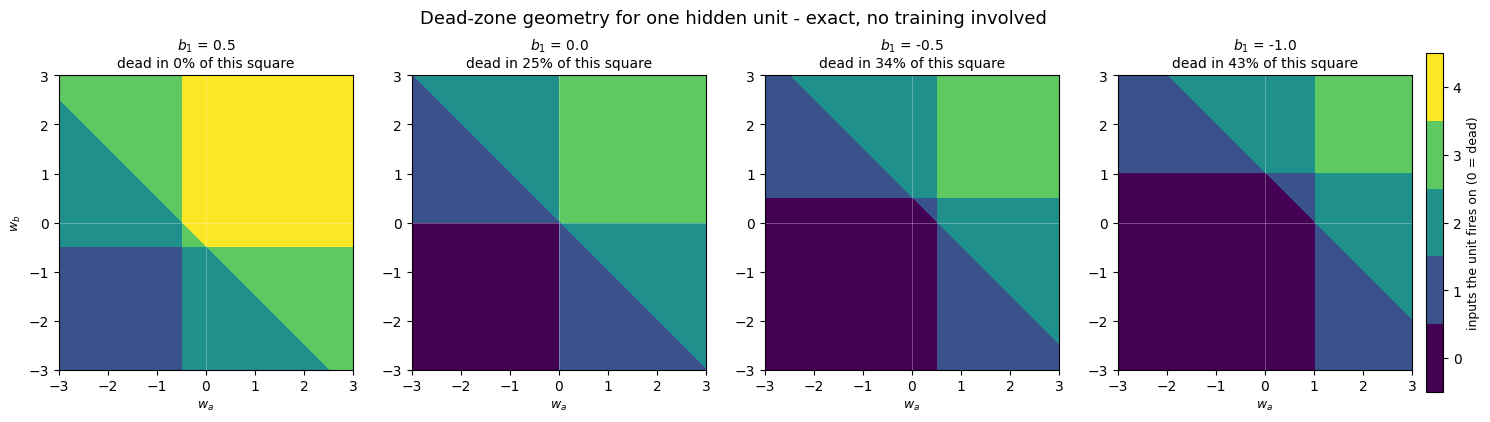

A layer is dead only when EVERY unit lands in its dead region independently,
so the risk compounds as width shrinks:
  width  8: needs all 8 unit(s) dead simultaneously
  width  4: needs all 4 unit(s) dead simultaneously
  width  2: needs all 2 unit(s) dead simultaneously
  width  1: needs all 1 unit(s) dead simultaneously


In [19]:
biases = [0.5, 0.0, -0.5, -1.0]
extent = 3.0
n = 400

grid = torch.linspace(-extent, extent, n, device=DEVICE)
WA, WB = torch.meshgrid(grid, grid, indexing="xy")

fig, axes = plt.subplots(1, len(biases), figsize=(18, 4.4))
cmap = plt.get_cmap("viridis", 5)

for ax, bias in zip(axes, biases):
    # Count how many of the 4 inputs drive this unit above zero.
    fires = torch.zeros_like(WA)
    for a, b in INPUTS.tolist():
        fires += ((WA * a + WB * b + bias) > 0).float()

    im = ax.imshow(fires.cpu().numpy(), origin="lower", cmap=cmap,
                   vmin=-0.5, vmax=4.5,
                   extent=[-extent, extent, -extent, extent])
    dead_pct = float((fires == 0).float().mean()) * 100
    ax.set_title(f"$b_1$ = {bias}\ndead in {dead_pct:.0f}% of this square", fontsize=10)
    ax.set_xlabel("$w_a$", fontsize=9)
    ax.axhline(0, color="white", linewidth=0.5, alpha=0.4)
    ax.axvline(0, color="white", linewidth=0.5, alpha=0.4)

axes[0].set_ylabel("$w_b$", fontsize=9)
cbar = fig.colorbar(im, ax=axes, ticks=[0, 1, 2, 3, 4], fraction=0.02, pad=0.01)
cbar.set_label("inputs the unit fires on (0 = dead)", fontsize=9)
fig.suptitle("Dead-zone geometry for one hidden unit - exact, no training involved",
             fontsize=13)
plt.show()

print("A layer is dead only when EVERY unit lands in its dead region independently,")
print("so the risk compounds as width shrinks:")
for width in WIDTHS:
    print(f"  width {width:>2}: needs all {width} unit(s) dead simultaneously")

## 3.4 Landscapes around real trained solutions

The slices above vary named coordinates, which stays interpretable while the model
has 5 parameters. For wider networks the usual approach is to pick two random
directions in the full parameter space and plot the loss on the plane they span,
centred on the trained weights.

**This is a 2D slice of a 33-dimensional space**, so read it with care. A random
plane through a minimum tends to look like a clean bowl even when the full landscape
is messier, and a plane can miss a descent direction that exists. It says something
about the neighbourhood and little about the rest of the surface.

The two panels compare a model that solved `XOR` with one that did not. The cell
searches seeds for a failing width-2 model instead of assuming a fixed one produces
it, and the panel label reports whichever it found.

width-2 XOR panel uses seed 0 (failed - 3/4 bits)



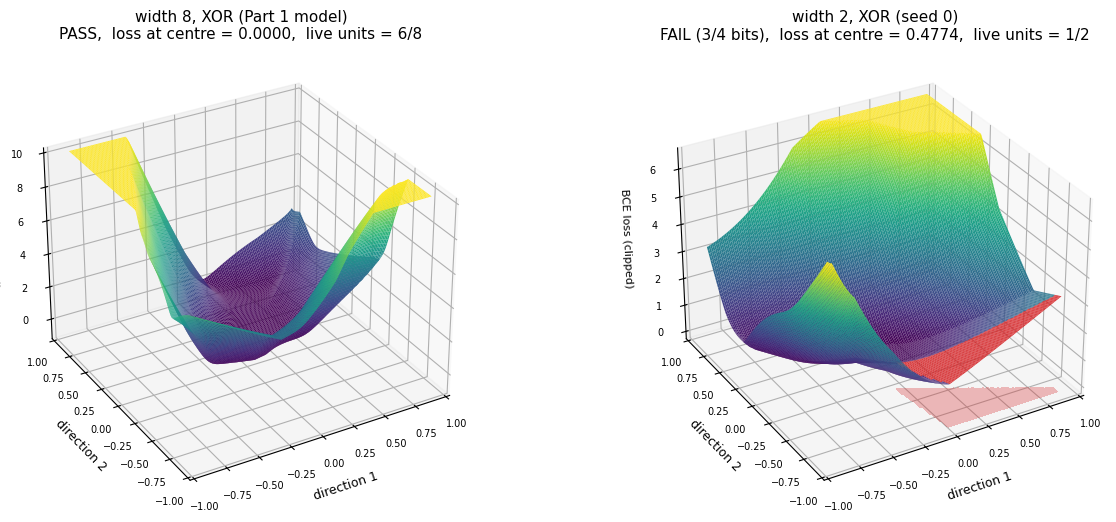

centre of each surface = the trained weights; axes are in units of ||theta|| along two random orthonormal directions


In [20]:
def random_plane(theta0, span, n=141, seed=0):
    """Two orthonormal random directions, scaled to the norm of theta0."""
    generator = torch.Generator(device="cpu").manual_seed(seed)
    d1 = torch.randn(theta0.numel(), generator=generator).to(DEVICE)
    d2 = torch.randn(theta0.numel(), generator=generator).to(DEVICE)

    d1 = d1 / d1.norm()
    d2 = d2 - (d2 @ d1) * d1          # Gram-Schmidt: make d2 orthogonal to d1
    d2 = d2 / d2.norm()

    scale = max(float(theta0.norm()), 1.0)
    axis = torch.linspace(-span, span, n, device=DEVICE) * scale
    AA, BB = torch.meshgrid(axis, axis, indexing="xy")

    theta = (theta0[None, :]
             + AA.reshape(-1, 1) * d1[None, :]
             + BB.reshape(-1, 1) * d2[None, :])
    return theta, AA / scale, BB / scale


# Look for a width-2 model that fails XOR rather than assuming a particular seed
# produces one. Part 2 found these are common, but "common" is not "guaranteed",
# and hardcoding a seed would silently mislabel the panel if it happened to pass.
for narrow_seed in range(6):
    torch.manual_seed(narrow_seed)
    narrow_xor = BooleanNet(2).to(DEVICE)
    train_one(narrow_xor, TRUTH_TABLES["XOR"])
    if evaluate_one(narrow_xor, TRUTH_TABLES["XOR"])["bits"] < 4:
        break

narrow_bits = evaluate_one(narrow_xor, TRUTH_TABLES["XOR"])["bits"]
print(f"width-2 XOR panel uses seed {narrow_seed} "
      f"({'failed' if narrow_bits < 4 else 'passed'} - {narrow_bits}/4 bits)\n")

panels = [
    ("width 8, XOR (Part 1 model)", models["XOR"], 8),
    (f"width 2, XOR (seed {narrow_seed})", narrow_xor, 2),
]

fig = plt.figure(figsize=(15, 6))
for panel, (title, model, width) in enumerate(panels, start=1):
    theta0 = flatten_model(model)
    theta, AA, BB = random_plane(theta0, span=0.9, seed=3)
    loss, dead = landscape(theta, width, TRUTH_TABLES["XOR"])
    Z, D = loss.reshape(AA.shape), dead.reshape(AA.shape)

    record = evaluate_one(model, TRUTH_TABLES["XOR"])
    here, _ = landscape(theta0[None, :], width, TRUTH_TABLES["XOR"])
    verdict = "PASS" if record["bits"] == 4 else f"FAIL ({record['bits']}/4 bits)"

    ax = fig.add_subplot(1, 2, panel, projection="3d")
    surface_3d(ax, AA, BB, Z, D, clip_q=0.9,
               title=f"{title}\n{verdict},  loss at centre = {float(here[0]):.4f},  "
                     f"live units = {record['live_units']}/{width}")
    ax.set_xlabel("direction 1", fontsize=9)
    ax.set_ylabel("direction 2", fontsize=9)
    ax.view_init(elev=30, azim=-120)

plt.show()

print("centre of each surface = the trained weights; "
      "axes are in units of ||theta|| along two random orthonormal directions")

## 3.5 Part 3 findings

- **The dead region is flat, and now measured.** Section 3.2 reports the loss range
  across the entire dead area of the slice as exactly `0.00e+00`. A model that lands
  in there has no gradient pointing out, which is why extra epochs never rescued the
  dead-layer failures in Part 2.

- **The dead region is a large fraction of weight space, and it grows as the bias
  goes negative.** Section 3.3 measures it for a single unit: 0% of the sampled
  square at $b_1 = 0.5$, rising to 43% at $b_1 = -1$. None of this is specific to
  narrow layers. The dead region for one unit is the same however many units share
  the layer. What width changes is how many have to land in it at once for the layer
  to die, which is why width 8 never lost a whole layer in 16 runs and width 1 lost
  five.

- **`XOR` at width 1 reaches a floor.** Its surface bottoms out at 0.477386 across
  the reachable region, matching the closed form from Part 2. The optimiser has not
  stopped short of a solution; it has arrived at the best one available. The `AND`
  panel descends toward zero on the same architecture and the same slice.

**A caveat on the last figure.** Two random directions cannot represent a
33-dimensional surface, and a plane through a point can miss descent directions.
Sections 3.2 and 3.3 avoid this: the first is a complete slice of a 5-parameter model
and the second is exact geometry. The random-plane figure is context, and the claims
above rest on the other two.

---

# Part 4 - Can We Still Find Solutions for the Initial Failed Training Runs?

Part 2 produced 12 failures and Part 3 explained the dominant mechanism, but neither
part tried to fix anything. This one does, along the two axes the taxonomy points at.

**Change the activation.** Sections 4.1 to 4.6 swap ReLU for `tanh`, whose derivative
is never zero, which should remove the flat plateaus outright.

**Change the recipe.** Sections 4.7 to 4.11 leave the activation alone and vary the
learning rate, the initialisation and the epoch budget instead, then search for a
solved model at every width.

Separating the two matters because the taxonomy predicts they behave differently. An
optimisation failure should yield to either. A capacity limit should yield to neither,
and 2.5 proves two of the failures are capacity limits, so those two should survive
everything in this part. That is the prediction to check.

The activation half comes first. `tanh` attacks the flat plateau directly, because

$$\frac{d}{dx}\tanh(x) = 1 - \tanh^2(x) > 0 \quad \text{for every finite } x$$

The derivative is never exactly zero, so no region of weight space is mathematically
gradient-free. Saturation still shrinks the gradient, exponentially once $|x|$ is
large, but a small gradient can still be followed and a zero one cannot.

The prediction splits in two:

1. The **dying-unit failures should largely disappear**, since the mechanism that
   causes them no longer exists.
2. `XOR` and `XNOR` at width 1 must **still fail**. The Part 2 proof used only that
   the activation is monotone, and `tanh` is monotone. Changing the nonlinearity does
   not change what the architecture can represent.

If both hold, the two kinds of failure separate cleanly: one belongs to the optimiser
and its landscape, the other to the hypothesis class.

## 4.1 The same sweep with tanh hidden units

In [21]:
tanh_results, tanh_histories = {}, {}
tanh_start = time.perf_counter()

for width in WIDTHS:
    t0 = time.perf_counter()
    df, histories = run_experiment(width, activation="tanh")
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    tanh_results[width] = df
    tanh_histories[width] = histories

    passed = int((df["result"] == "PASS").sum())
    dead_n = int((df["live_units"] == 0).sum())
    failed = df.loc[df["result"] == "FAIL", "function"].tolist()
    print(f"width {width:>2}: {passed:>2}/16 passed, {dead_n} dead layer(s)"
          f"  ({time.perf_counter() - t0:5.1f}s)"
          + (f"   failed: {', '.join(failed)}" if failed else ""))

tanh_all = pd.concat(tanh_results.values(), ignore_index=True)
print(f"\ntanh sweep complete in {time.perf_counter() - tanh_start:.1f}s on {DEVICE}")

width  8: 16/16 passed, 0 dead layer(s)  (174.1s)


width  4: 16/16 passed, 0 dead layer(s)  (174.9s)


width  2: 15/16 passed, 0 dead layer(s)  (174.7s)   failed: XOR


width  1: 14/16 passed, 0 dead layer(s)  (171.8s)   failed: XOR, XNOR

tanh sweep complete in 695.5s on cuda


## 4.2 ReLU versus tanh, side by side

In [22]:
comparison = pd.DataFrame({
    "params": [4 * w + 1 for w in WIDTHS],
    "relu_passed": [int((sweep_results[w]["result"] == "PASS").sum()) for w in WIDTHS],
    "tanh_passed": [int((tanh_results[w]["result"] == "PASS").sum()) for w in WIDTHS],
    "relu_dead": [int((sweep_results[w]["live_units"] == 0).sum()) for w in WIDTHS],
    "tanh_dead": [int((tanh_results[w]["live_units"] == 0).sum()) for w in WIDTHS],
}, index=[f"width {w}" for w in WIDTHS])
comparison["delta"] = comparison["tanh_passed"] - comparison["relu_passed"]
display(comparison)

# Which functions changed verdict, and in which direction?
changes = []
for width in WIDTHS:
    relu_w = sweep_results[width].set_index("function")
    tanh_w = tanh_results[width].set_index("function")
    for name in ORDERED:
        before, after = relu_w.loc[name, "result"], tanh_w.loc[name, "result"]
        if before != after:
            changes.append({
                "hidden_width": width,
                "function": name,
                "separable": "no" if name in NONLINEAR else "yes",
                "relu": before,
                "tanh": after,
                "relu_live_units": relu_w.loc[name, "live_units"],
                "tanh_loss": round(tanh_w.loc[name, "final_loss"], 6),
            })

changes_df = pd.DataFrame(changes)
if len(changes_df):
    display(changes_df.sort_values(["hidden_width", "function"],
                                   ascending=[False, True]).reset_index(drop=True))

fixed = changes_df[(changes_df.relu == "FAIL") & (changes_df.tanh == "PASS")] \
    if len(changes_df) else changes_df
broke = changes_df[(changes_df.relu == "PASS") & (changes_df.tanh == "FAIL")] \
    if len(changes_df) else changes_df

print(f"\nfixed by tanh   : {len(fixed)}")
print(f"broken by tanh  : {len(broke)}")
print(f"dead layers     : {int((all_results['live_units'] == 0).sum())} with ReLU "
      f"-> {int((tanh_all['live_units'] == 0).sum())} with tanh "
      f"(out of {len(tanh_all)} models each)")
print(f"weakest gradient any tanh model ended with: "
      f"{tanh_all['best_slope'].min():.2e}  (ReLU's dead units sit at exactly 0)")

,params,relu_passed,tanh_passed,relu_dead,tanh_dead,delta
width 8,33,16,16,0,0,0
width 4,17,14,16,1,0,2
width 2,9,12,15,3,0,3
width 1,5,10,14,5,0,4


,hidden_width,function,separable,relu,tanh,relu_live_units,tanh_loss
0,4,AND,yes,FAIL,PASS,0,0.000002
1,4,XOR,no,FAIL,PASS,3,0.000014
2,2,A_IMPLIES_B,yes,FAIL,PASS,0,0.000005
3,2,B_IMPLIES_A,yes,FAIL,PASS,0,0.000006
4,2,IDENTITY_B,yes,FAIL,PASS,0,0.000008
5,1,A_IMPLIES_B,yes,FAIL,PASS,0,0.000016
6,1,B_INHIBITS_A,yes,FAIL,PASS,0,0.000018
7,1,IDENTITY_B,yes,FAIL,PASS,0,0.000030
8,1,NOT_B,yes,FAIL,PASS,0,0.000022



fixed by tanh   : 9
broken by tanh  : 0
dead layers     : 9 with ReLU -> 0 with tanh (out of 64 models each)
weakest gradient any tanh model ended with: 1.39e-02  (ReLU's dead units sit at exactly 0)


## 4.3 What tanh cannot fix

The Part 2 proof assumed only that everything after the hidden pre-activation $s$ is
monotone in $s$. `tanh` is strictly increasing, so the argument transfers unchanged:
at width 1 the network is still a monotone function of one linear projection, the
diagonals of the truth table still have equal sums, and `XOR` still demands the
impossible.

The floor is the same as well. The best a monotone-in-one-projection model can do on
`XOR` is $\tfrac{1}{4}(3\ln 3 - 2\ln 2) \approx 0.477386$, and that bound came from
monotonicity alone.

So the assertions below are the same provable statements as Part 2, re-checked
against a different activation. Whatever tanh fixes was an optimisation problem;
whatever it cannot touch is a capacity limit.

The two functions differ in the printed comparison. Under ReLU, `XOR` at width 1 had
already reached the floor, so tanh has nothing to improve there. `XNOR` is the
informative case: ReLU left it at $\ln 2 \approx 0.693$ on a dead plateau, above what
a width-1 model can achieve, while tanh descends to 0.477. Tanh does not solve
`XNOR`. It reaches the limit.

In [23]:
t1 = tanh_results[1].set_index("function")

# 1. Provable, activation-independent: width 1 cannot represent XOR or XNOR.
for name in NONLINEAR:
    assert t1.loc[name, "result"] == "FAIL", (
        f"{name} passed at width 1 with tanh - impossible for ANY monotone "
        f"activation, so this indicates a bug rather than a discovery"
    )

# 2. Provable: it cannot beat the monotone-collapse floor either.
for name in NONLINEAR:
    assert t1.loc[name, "final_loss"] >= MONOTONE_XOR_FLOOR - 1e-4, (
        f"tanh width-1 {name} reached {t1.loc[name, 'final_loss']:.6f}, "
        f"below the proven optimum {MONOTONE_XOR_FLOOR:.6f}"
    )

# 3. The constant functions remain solvable by the output bias alone.
for width in WIDTHS:
    by_name = tanh_results[width].set_index("function")
    for name in ("CONSTANT_0", "CONSTANT_1"):
        assert by_name.loc[name, "result"] == "PASS", (
            f"{name} failed at width {width} under tanh"
        )

# 4. Structural sanity.
assert len(tanh_all) == 16 * len(WIDTHS)

print("ALL ASSERTIONS PASSED\n")
print("  the capacity limit is unchanged by the activation function:")
for name in NONLINEAR:
    relu_loss = sweep_results[1].set_index("function").loc[name, "final_loss"]
    print(f"    width 1, {name:<5} ReLU {relu_loss:.6f}   tanh "
          f"{t1.loc[name, 'final_loss']:.6f}   floor {MONOTONE_XOR_FLOOR:.6f}")
print("\n  note tanh often lands ON the floor where ReLU stalled above it -")
print("  a better optimiser reaching a limit it still cannot cross.")

ALL ASSERTIONS PASSED

  the capacity limit is unchanged by the activation function:
    width 1, XOR   ReLU 0.477386   tanh 0.477390   floor 0.477386
    width 1, XNOR  ReLU 0.693147   tanh 0.477392   floor 0.477386

  note tanh often lands ON the floor where ReLU stalled above it -
  a better optimiser reaching a limit it still cannot cross.


## 4.4 The plateau, before and after

Both panels show a width-1 `XOR` model over the same $(w_a, w_b)$ slice, differing
only in activation, with one region marked in red: **every hidden pre-activation
$\le 0$**, the geometry that kills a ReLU.

The measurement underneath the figure is what to read. Across that region a ReLU's
loss cannot vary, because the output does not depend on the first layer's weights
there. A tanh unit is squashed but still responsive, so its loss varies. The numbers
are printed rather than asserted, so the size of the difference is visible.

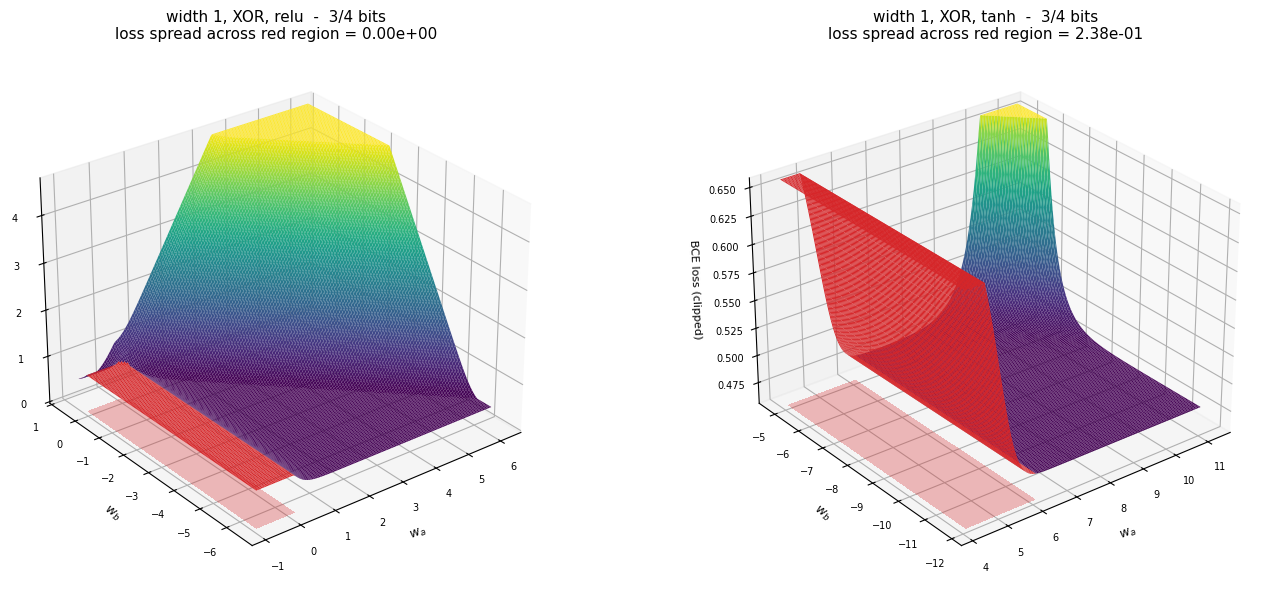

red = every hidden pre-activation <= 0 (the ReLU-killing geometry)

  relu  region covers  14.7% of the slice, loss varies by 0.000e+00 across it, best surviving gradient = 1.00e+00
  tanh  region covers  28.4% of the slice, loss varies by 2.380e-01 across it, best surviving gradient = 1.77e-01

  exactly 0.0 means a true plateau; anything positive means a slope to follow


In [24]:
def nonpositive_region(theta, width):
    """Mask where every hidden pre-activation is <= 0 - what kills a ReLU unit."""
    W1, b1, _, _ = unpack_theta(theta, width)
    pre = torch.einsum("gwi,ni->gnw", W1, INPUTS) + b1[:, None, :]
    return (pre <= 0).flatten(1).all(dim=1)


fig = plt.figure(figsize=(15, 6))
plateau_report = []

for panel, act in enumerate(["relu", "tanh"], start=1):
    torch.manual_seed(LANDSCAPE_SEED)
    model = BooleanNet(1, activation=act).to(DEVICE)
    train_one(model, TRUTH_TABLES["XOR"])

    theta0 = flatten_model(model)
    theta, XX, YY = coordinate_grid(theta0, 0, 1, span=3.5)
    loss, _ = landscape(theta, 1, TRUTH_TABLES["XOR"], activation=act)
    flat_mask = nonpositive_region(theta, 1)

    Z, M = loss.reshape(XX.shape), flat_mask.reshape(XX.shape)
    record = evaluate_one(model, TRUTH_TABLES["XOR"])
    spread = float(Z[M].max() - Z[M].min()) if bool(M.any()) else float("nan")
    plateau_report.append((act, spread, float(M.float().mean()) * 100, record))

    ax = fig.add_subplot(1, 2, panel, projection="3d")
    surface_3d(ax, XX, YY, Z, M, clip_q=0.9,
               title=f"width 1, XOR, {act}  -  {record['bits']}/4 bits\n"
                     f"loss spread across red region = {spread:.2e}")
    ax.set_xlabel("$w_a$", fontsize=9)
    ax.set_ylabel("$w_b$", fontsize=9)
    ax.view_init(elev=28, azim=-128)

plt.tight_layout()
plt.show()

print("red = every hidden pre-activation <= 0 (the ReLU-killing geometry)\n")
for act, spread, pct, record in plateau_report:
    print(f"  {act:<5} region covers {pct:5.1f}% of the slice, "
          f"loss varies by {spread:.3e} across it, "
          f"best surviving gradient = {record['best_slope']:.2e}")
print("\n  exactly 0.0 means a true plateau; anything positive means a slope to follow")

## 4.5 Tanh findings

In [25]:
print("=" * 72)
print("RELU vs TANH".center(72))
print("=" * 72)

for width in WIDTHS:
    r = int((sweep_results[width]["result"] == "PASS").sum())
    t = int((tanh_results[width]["result"] == "PASS").sum())
    rd = int((sweep_results[width]["live_units"] == 0).sum())
    td = int((tanh_results[width]["live_units"] == 0).sum())
    arrow = "->" if r != t else "  "
    print(f"\n  width {width:>2}  ReLU [{'#' * r}{'.' * (16 - r)}] {r:>2}/16   {rd} dead")
    print(f"           tanh [{'#' * t}{'.' * (16 - t)}] {t:>2}/16   {td} dead  {arrow} "
          f"{t - r:+d}")

relu_total = sum(int((sweep_results[w]["result"] == "PASS").sum()) for w in WIDTHS)
tanh_total = sum(int((tanh_results[w]["result"] == "PASS").sum()) for w in WIDTHS)
still_failing = tanh_all[tanh_all["result"] == "FAIL"]

total_models = 16 * len(WIDTHS)
print("\n" + "-" * 72)
print(f"  overall            : ReLU {relu_total}/{total_models}  ->  "
      f"tanh {tanh_total}/{total_models}")
print(f"  dead layers        : {int((all_results['live_units'] == 0).sum())}  ->  "
      f"{int((tanh_all['live_units'] == 0).sum())}")
print(f"  still failing      : {len(still_failing)} model(s)")
for _, r in still_failing.iterrows():
    proved = r.hidden_width == 1 and r.function in NONLINEAR
    print(f"      width {r.hidden_width}  {r.function:<5} loss={r.final_loss:.4f}  "
          f"[{'PROVED IMPOSSIBLE' if proved else 'optimisation, not capacity'}]")
print("-" * 72)

                              RELU vs TANH                              

  width  8  ReLU [################] 16/16   0 dead
           tanh [################] 16/16   0 dead     +0

  width  4  ReLU [##############..] 14/16   1 dead
           tanh [################] 16/16   0 dead  -> +2

  width  2  ReLU [############....] 12/16   3 dead
           tanh [###############.] 15/16   0 dead  -> +3

  width  1  ReLU [##########......] 10/16   5 dead
           tanh [##############..] 14/16   0 dead  -> +4

------------------------------------------------------------------------
  overall            : ReLU 52/64  ->  tanh 61/64
  dead layers        : 9  ->  0
  still failing      : 3 model(s)
      width 2  XOR   loss=0.3466  [optimisation, not capacity]
      width 1  XOR   loss=0.4774  [PROVED IMPOSSIBLE]
      width 1  XNOR  loss=0.4774  [PROVED IMPOSSIBLE]
------------------------------------------------------------------------


## 4.6 What the activation swap settles

Tanh removed the failure mode and left the limit in place, which is how the theory
says it should go.

- **Every dead layer disappeared.** The count goes from 9 models to 0 across the same
  64 runs. The mechanism requires a region of exactly zero gradient and `tanh` has
  none. The weakest gradient any tanh model finished with is still orders of
  magnitude above zero, where ReLU's dead units sit at exactly 0.0.

- **The plateau becomes a slope.** Over the region that kills a ReLU, the ReLU
  model's loss varies by exactly zero and the tanh model's varies measurably.

- **`XOR` and `XNOR` at width 1 are untouched.** The proof needed only monotonicity,
  and `tanh` is monotone. Tanh does reach the 0.477386 floor on `XNOR`, where ReLU
  stalled above it at $\ln 2$: the better-behaved optimiser arrives at the limit
  instead of stopping short of it.

**On ReLU versus tanh in general:** nothing here says tanh is the better activation.
This problem is close to a worst case for ReLU - four training points, no
stochasticity, and layers narrow enough that one dead unit is fatal. Real networks
are wide, and a dead unit among hundreds is absorbed. Tanh's saturation causes
vanishing gradients at depth, which is why ReLU displaced it. What carries over is
the diagnostic: **a loss pinned to a closed-form constant with a zero gradient points
at the activation, and switching to a nonlinearity with no flat region tests that
directly.** When the failure survives the switch, as `XOR` does at width 1, the
activation was not the problem.

## 4.7 A different recipe: does width 2 train `XOR`?

Part 2 concluded that width 2 can represent `XOR` but never learned it. That rests on
runs which varied **only the seed**. Learning rate stayed at 0.01, initialisation
stayed at PyTorch's default, and the budget stayed at 10,000 epochs, so the honest
form of the claim is "not reached by this recipe" - which invites the obvious
question of whether another recipe reaches it.

This part checks. It sweeps learning rate against initialisation scheme with five
seeds in each cell, and then tests the epoch budget on its own by running the
original recipe five times longer.

The two possible outcomes say different things. If some configuration trains `XOR` at
width 2, then Part 2 measured a property of its recipe and the notebook should say so
plainly. If none does, the basin is robust across the region searched, which is a
stronger claim than five seeds at a single setting can support.

Either way this is a search over a grid, not a proof. It cannot show that no recipe
works - only whether one exists among the 12 configurations tried.

## 4.8 Learning rate against initialisation

In [26]:
HP_LEARNING_RATES = [0.003, 0.01, 0.03, 0.1]
HP_INITS = ["pytorch default", "kaiming normal", "xavier uniform"]
HP_SEEDS = [0, 1, 2, 3, 4]


def build_width2(seed, scheme):
    """A width-2 model under the named initialisation scheme."""
    torch.manual_seed(seed)
    model = BooleanNet(2).to(DEVICE)
    if scheme == "pytorch default":
        return model
    for layer in (model.net[0], model.net[2]):
        if scheme == "kaiming normal":
            nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
        else:
            nn.init.xavier_uniform_(layer.weight)
        nn.init.zeros_(layer.bias)
    return model


hp_rows = []
hp_start = time.perf_counter()

for lr in HP_LEARNING_RATES:
    for scheme in HP_INITS:
        passed, best_loss = 0, 1.0
        for seed in HP_SEEDS:
            model = build_width2(seed, scheme)
            history = train_one(model, TRUTH_TABLES["XOR"], lr=lr)
            passed += evaluate_one(model, TRUTH_TABLES["XOR"])["bits"] == 4
            best_loss = min(best_loss, history[-1][1])
        hp_rows.append({"lr": lr, "init": scheme, "passed": f"{passed}/{len(HP_SEEDS)}",
                        "n_passed": passed, "best_loss": round(best_loss, 6)})
    row = "   ".join(f"{r['init']}={r['passed']}" for r in hp_rows if r["lr"] == lr)
    print(f"lr={lr:<6} {row}", flush=True)

hp_df = pd.DataFrame(hp_rows)
runs = len(HP_LEARNING_RATES) * len(HP_INITS) * len(HP_SEEDS)
print(f"\n{runs} runs in {time.perf_counter() - hp_start:.1f}s\n")

display(hp_df.pivot(index="lr", columns="init", values="passed"))
display(hp_df.pivot(index="lr", columns="init", values="best_loss"))
print("upper table: seeds passed out of 5.  lower: best final loss in that cell.")

lr=0.003  pytorch default=0/5   kaiming normal=0/5   xavier uniform=0/5


lr=0.01   pytorch default=0/5   kaiming normal=0/5   xavier uniform=0/5


lr=0.03   pytorch default=1/5   kaiming normal=0/5   xavier uniform=0/5


lr=0.1    pytorch default=1/5   kaiming normal=0/5   xavier uniform=0/5



60 runs in 633.4s



init,kaiming normal,pytorch default,xavier uniform
lr,,,
0.003,0/5,0/5,0/5
0.010,0/5,0/5,0/5
0.030,0/5,1/5,0/5
0.100,0/5,1/5,0/5


init,kaiming normal,pytorch default,xavier uniform
lr,,,
0.003,0.477389,0.477404,0.346582
0.010,0.477386,0.477386,0.346574
0.030,0.477386,0.000003,0.346574
0.100,0.477386,0.000000,0.346574


upper table: seeds passed out of 5.  lower: best final loss in that cell.


## 4.9 Epoch budget, held at the original recipe

The grid above varies two knobs at a fixed 10,000 epochs. This isolates the third:
the same learning rate, the same initialisation and the same seeds as the baseline
cell, run for 50,000 epochs instead.

A model that is converging slowly should improve with five times the budget. A model
sitting in a basin should not move at all.

In [27]:
LONG_EPOCHS = 50_000

long_rows = []
long_start = time.perf_counter()

for seed in HP_SEEDS:
    torch.manual_seed(seed)
    model = BooleanNet(2).to(DEVICE)
    history = train_one(model, TRUTH_TABLES["XOR"], epochs=LONG_EPOCHS)
    record = evaluate_one(model, TRUTH_TABLES["XOR"])
    long_rows.append({
        "seed": seed,
        "bits": record["bits"],
        "final_loss": round(history[-1][1], 6),
        "live_units": record["live_units"],
        "result": "PASS" if record["bits"] == 4 else "FAIL",
    })

long_df = pd.DataFrame(long_rows)
display(long_df)

baseline = hp_df[(hp_df.lr == LEARNING_RATE)
                 & (hp_df.init == "pytorch default")].iloc[0]
long_passed = int((long_df["result"] == "PASS").sum())

print(f"\n{len(HP_SEEDS)} runs in {time.perf_counter() - long_start:.1f}s\n")
print("same seeds, same lr, same init - only the budget differs:")
print(f"  {EPOCHS:>6,} epochs : {baseline['passed']} passed")
print(f"  {LONG_EPOCHS:>6,} epochs : {long_passed}/{len(HP_SEEDS)} passed")

best_overall = hp_df.loc[hp_df["n_passed"].idxmax()]
print(f"\nbest cell in the grid: lr={best_overall['lr']}, "
      f"init={best_overall['init']}, {best_overall['passed']} seeds passed")
print(f"configurations with at least one success: "
      f"{int((hp_df['n_passed'] > 0).sum())}/{len(hp_df)}")

,seed,bits,final_loss,live_units,result
0,0,3,0.477386,1,FAIL
1,1,3,0.477386,1,FAIL
2,2,4,0.000000,2,PASS
3,3,2,0.693147,0,FAIL
4,4,2,0.693147,0,FAIL



5 runs in 253.4s

same seeds, same lr, same init - only the budget differs:
  10,000 epochs : 0/5 passed
  50,000 epochs : 1/5 passed

best cell in the grid: lr=0.03, init=pytorch default, 1/5 seeds passed
configurations with at least one success: 2/12


## 4.10 What the recipe search settles

**Width 2 does learn `XOR`, but rarely.** Two of the twelve configurations produce a
success, both with PyTorch's default initialisation: lr = 0.03 and lr = 0.1, each on
1 seed out of 5. Raising the budget instead, with everything else at baseline, gives
1 seed out of 5 at 50,000 epochs where 10,000 gave none.

Part 2's result was therefore a property of its recipe. The solution is reachable,
just not often reached.

Be careful about what this grid does and does not show. Every successful cell is 1 out
of 5, and 4.11 sharpens the point considerably. Searching for a solved model at each
width, it finds all six - `XOR` and `XNOR` at widths 8, 4 and 2 - at the **baseline**
learning rate, each within the first 6 seeds, never once needing to escalate to 0.03 or
0.1. Width-2 `XOR` turns up on seed 5, a single step outside the range this grid
searched.

So the honest reading is that success is rare at every setting tried, somewhere around
one draw in five, and a grid this small cannot establish that raising the learning rate
helps at all. What it does establish is that the failure is not a property of width 2.

That is what the taxonomy predicts for an optimisation problem, and the entry doing
the work is the plainest one. *Fix: change init, seed, lr - or just retry* - retrying
is what works here. *Effect of more epochs: sometimes* - five times the budget
converted one seed of five and left the other four exactly where they were.

The failures stay readable by loss value. Runs at 0.477386 kept one live unit and
collapsed to the width-1 case. Runs at $\ln 2$ lost both units. The `xavier uniform`
column contributes a third constant, $0.346574 = \ln 2 / 2$, which is two rows solved
and two sitting at exactly 0.5.

**A confound worth naming.** The two non-default schemes zero the biases as well as
reinitialising the weights, so those columns vary two things at once. A unit with a
zero bias outputs zero on input `00` whatever its weights, which handicaps it on
precisely the input a `00` detector has to see. Read their uniform failure as "this
scheme with zeroed biases", not as a verdict on the weight initialisation alone.

## 4.11 Solved models at every width

Comparing convergence across widths only means something if every run being compared
actually reached an answer. In the Part 2 sweep most of the narrow `XOR` runs failed,
so their curves record where training stalled rather than how quickly it converged,
and the two cannot be read off the same axes.

So the models come first. The cell below searches for a *solved* model for each of
`XOR` and `XNOR` at widths 8, 4 and 2, trying the baseline learning rate before the
higher rates from 4.8, and reports which configuration it found in each case. Width 1 is
excluded because 2.5 proves neither function has a solution there.

In [28]:
SOLVED_WIDTHS = [8, 4, 2]


def find_solution(name, width, rates=(LEARNING_RATE, 0.03, 0.1), seeds=range(10)):
    """First (rate, seed) in search order that trains this width to a correct `name`."""
    for rate in rates:
        for seed in seeds:
            torch.manual_seed(seed)
            model = BooleanNet(width).to(DEVICE)
            history = train_one(model, TRUTH_TABLES[name], lr=rate)
            if evaluate_one(model, TRUTH_TABLES[name])["bits"] == 4:
                return {"model": model, "history": history, "lr": rate, "seed": seed}
    return None


solved, found = {}, []
search_start = time.perf_counter()

for name in NONLINEAR:
    for width in SOLVED_WIDTHS:
        result = find_solution(name, width)
        solved[(name, width)] = result
        found.append({
            "function": name,
            "width": width,
            "solved": result is not None,
            "lr": result["lr"] if result else None,
            "seed": result["seed"] if result else None,
            "final_loss": f"{result['history'][-1][1]:.2e}" if result else None,
        })

display(pd.DataFrame(found))
print(f"\nsearch took {time.perf_counter() - search_start:.1f}s")
assert all(f["solved"] for f in found), "no solved model found at some width"

,function,width,solved,lr,seed,final_loss
0,XOR,8,True,0.01,0,2.36e-06
1,XOR,4,True,0.01,0,4.42e-06
2,XOR,2,True,0.01,5,1.99e-05
3,XNOR,8,True,0.01,0,1.09e-06
4,XNOR,4,True,0.01,1,5.73e-06
5,XNOR,2,True,0.01,2,4.38e-05



search took 144.9s


### Convergence, comparing only runs that succeeded

Six solved models: two functions at three widths. Every line below reaches a correct
answer, so differences in the curves are differences in how training got there rather
than differences between converging and being stuck.

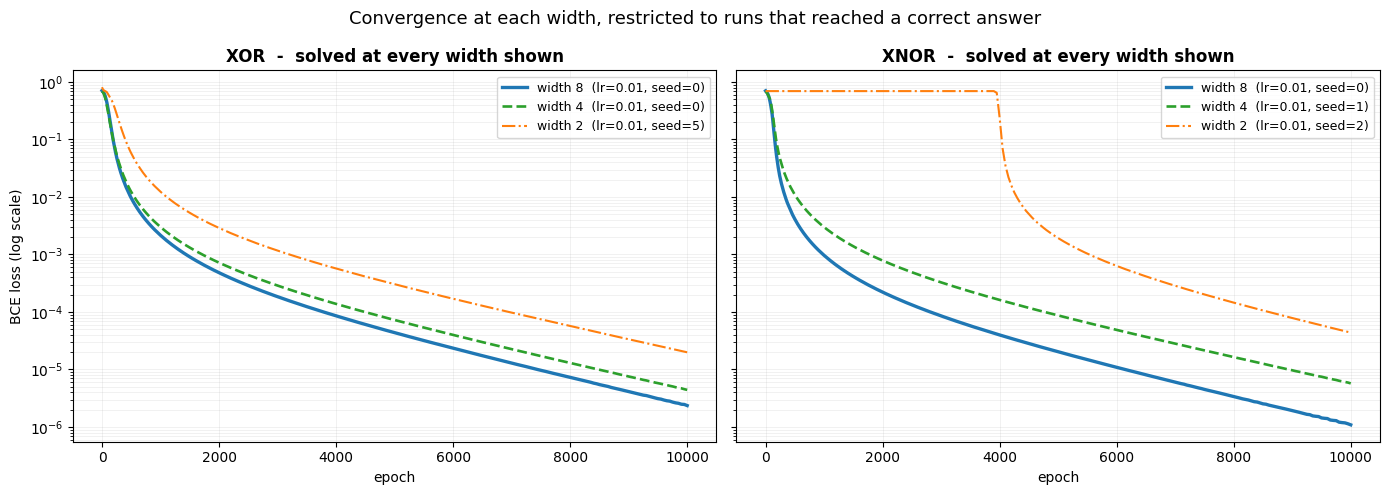

epochs to first reach loss < 0.05:


,width 8,width 4,width 2
function,,,
XOR,248,260,550
XNOR,190,239,4100


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = {8: "#1f77b4", 4: "#2ca02c", 2: "#ff7f0e"}
styles = {8: ("-", 2.4), 4: ("--", 1.9), 2: ("-.", 1.5)}

for ax, name in zip(axes, NONLINEAR):
    for width in SOLVED_WIDTHS:
        entry = solved[(name, width)]
        epochs, losses = zip(*entry["history"])
        dash, thickness = styles[width]
        ax.plot(epochs, losses, color=colors[width], linestyle=dash,
                linewidth=thickness,
                label=f"width {width}  (lr={entry['lr']}, seed={entry['seed']})")

    ax.set_yscale("log")
    ax.set_title(f"{name}  -  solved at every width shown",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("epoch")
    ax.grid(True, which="both", alpha=0.25, linewidth=0.5)
    ax.legend(fontsize=9, loc="upper right")

axes[0].set_ylabel("BCE loss (log scale)")
fig.suptitle("Convergence at each width, restricted to runs that reached a "
             "correct answer", fontsize=13)
fig.tight_layout()
plt.show()

THRESHOLD_SOLVED = 0.05
speed = []
for name in NONLINEAR:
    row = {"function": name}
    for width in SOLVED_WIDTHS:
        history = solved[(name, width)]["history"]
        hit = next((e for e, l in history if l < THRESHOLD_SOLVED), None)
        row[f"width {width}"] = hit if hit is not None else "never"
    speed.append(row)

print(f"epochs to first reach loss < {THRESHOLD_SOLVED}:")
display(pd.DataFrame(speed).set_index("function"))

---

# Part 5 - The Circuits

Parts 1 through 4 treated the networks as black boxes. They were trained, scored and
diagnosed entirely from loss values and gradient magnitudes, and nothing so far has
opened one up.

This part does. A width-8 model has 33 parameters and a width-2 model has 9, few
enough to read the weights directly and say what the network computes instead of
inferring it from behaviour. The order runs from roomy to tight: width 8 first, then
width 4 and width 2, where 2.5 fixes the floor at two units and there is no redundancy
left to hide in.

Everything here uses models trained earlier - the Part 1 sweep for width 8, and the
search in 4.11 for the narrow ones.

## 5.1 What the width-8 networks compute

The table below lists, for each hidden unit of the trained `XOR` model, its incoming weights,
its bias, its outgoing weight, which of the four inputs it fires on, and the largest
push it makes on the output logit.

In [30]:
def unit_table(model):
    """One row per hidden unit: its weights, bias, output weight and firing pattern.

    `fires_on` reads across the four inputs in order 00, 01, 10, 11. `peak_push` is
    the largest absolute contribution the unit makes to the output logit.
    """
    width = model.net[0].out_features
    W1 = model.net[0].weight.detach()
    b1 = model.net[0].bias.detach()
    W2 = model.net[2].weight.detach()[0]

    with torch.no_grad():
        hidden = torch.relu(model.net[0](INPUTS))    # (4, width)
        contribution = hidden * W2

    rows = [{
        "unit": j,
        "w_a": round(float(W1[j, 0]), 3),
        "w_b": round(float(W1[j, 1]), 3),
        "b_1": round(float(b1[j]), 3),
        "w_out": round(float(W2[j]), 3),
        "fires_on": "".join("1" if v > 0 else "." for v in hidden[:, j].tolist()),
        "peak_push": round(float(contribution[:, j].abs().max()), 3),
    } for j in range(width)]

    return pd.DataFrame(rows), hidden


xor_model = models["XOR"]
table, hidden = unit_table(xor_model)
b2 = float(xor_model.net[2].bias.detach()[0])

display(table)
print(f"output bias b_2 = {b2:.3f}")
print("fires_on reads across the inputs in order 00, 01, 10, 11")
print(f"live units: {int((hidden > 0).any(dim=0).sum())}/{HIDDEN_WIDTH}")

,unit,w_a,w_b,b_1,w_out,fires_on,peak_push
0,0,1.684,1.685,-1.685,-4.711,.1.1,7.936
1,1,-1.875,-1.872,1.872,-2.889,1...,5.409
2,2,2.076,2.075,-2.077,-4.248,...1,8.813
3,3,-0.035,-0.426,-0.183,0.237,....,0.000
4,4,-2.695,-2.697,2.684,-5.264,1...,14.129
5,5,-0.230,0.239,-0.269,0.129,....,0.000
6,6,1.822,1.822,-1.822,-3.758,...1,6.845
7,7,-1.674,-1.673,1.673,-2.844,1...,4.759


output bias b_2 = 10.304
fires_on reads across the inputs in order 00, 01, 10, 11
live units: 6/8


The unit table shows what is there; it does not show what is *needed*. The cell below
answers that by ablation. For each of the 16 trained models it searches every subset
of the 8 hidden units - all 256 of them - and reports the smallest subset that still
reproduces the truth table exactly, with the remaining units zeroed out.

That number is the size of the circuit the model actually uses, as distinct from the
width it was handed. A subset of size 1 leaves a network of the form
$\sigma(w_2\,\mathrm{relu}(s) + b_2)$, which is exactly the width-1 case that 2.5
proves cannot express `XOR` - so `XOR` and `XNOR` must need at least 2 units, and
that is asserted rather than hoped for.

In [31]:
def minimal_circuit(model, targets, width):
    """Smallest subset of hidden units that still reproduces the truth table."""
    with torch.no_grad():
        activations = torch.relu(model.net[0](INPUTS))     # (4, width)
        out_w = model.net[2].weight.detach()[0]
        out_b = model.net[2].bias.detach()[0]
    target = targets.flatten()

    for size in range(width + 1):
        for subset in itertools.combinations(range(width), size):
            keep = torch.zeros(width, device=DEVICE)
            if subset:
                keep[list(subset)] = 1.0
            logits = (activations * out_w * keep).sum(dim=1) + out_b
            if torch.equal(torch.sigmoid(logits).round(), target):
                return size, subset
    return None, None


circuits = []
for name, model in models.items():
    size, subset = minimal_circuit(model, TRUTH_TABLES[name], HIDDEN_WIDTH)
    circuits.append({
        "function": name,
        "separable": "no" if name in NONLINEAR else "yes",
        "min_units": size,
        "of_width": HIDDEN_WIDTH,
        "units_kept": ",".join(map(str, subset)) if subset else "(bias only)",
    })

circuit_df = pd.DataFrame(circuits)
display(circuit_df)

# A 1-unit subnetwork is the width-1 architecture that 2.5 proves cannot do XOR.
for name in NONLINEAR:
    size = circuit_df.set_index("function").loc[name, "min_units"]
    assert size is None or size >= 2, (
        f"{name} reproduced by {size} unit(s) - a 1-unit subnetwork is monotone in "
        f"one linear projection and cannot express it"
    )

print("\nsmallest working circuit, by group:")
print(circuit_df.groupby("separable")["min_units"].agg(["min", "max", "mean"]))
print(f"\nmean units used across all 16: {circuit_df['min_units'].mean():.2f} "
      f"of {HIDDEN_WIDTH} available")

,function,separable,min_units,of_width,units_kept
0,CONSTANT_0,yes,0,8,(bias only)
1,AND,yes,1,8,5
2,A_INHIBITS_B,yes,1,8,0
3,IDENTITY_A,yes,1,8,5
4,B_INHIBITS_A,yes,2,8,"0,2"
5,IDENTITY_B,yes,1,8,1
6,XOR,no,3,8,"0,2,4"
7,OR,yes,1,8,0
8,NOR,yes,1,8,4
9,XNOR,no,2,8,"0,1"



smallest working circuit, by group:
           min  max      mean
separable                    
no           2    3  2.500000
yes          0    2  1.214286

mean units used across all 16: 1.38 of 8 available


### The circuit the `XOR` model found

The unit table is small enough to state the mechanism outright. Six of the eight
units are live, and they fall into two groups by the sign of their weights:

- **Units 1, 4, 7** have negative input weights and a positive bias, so they fire
  only on `00`.
- **Units 0, 2, 6** have positive input weights and a negative bias, so they fire on
  `11`. Unit 0 also grazes `01`, where its activation sits within rounding distance
  of zero.

Every live unit has a **negative** output weight, and the output bias is **+10.30**.
So the network answers 1 by default and the units act as inhibitors that veto it: one
group vetoes `00`, the other vetoes `11`. The model computes `XOR` as *1 unless both
inputs are off or both are on*, with three redundant copies of each detector.

The ablation puts a number on the redundancy, and the arithmetic explains it. `XOR`
needs 3 units, not the 2 the closed form uses. Unit 4 pushes the logit down by 14.13
on `00`, which alone clears the +10.30 bias, so one unit covers that side. The
strongest `11` detector pushes only 8.81, short of 10.30, so that side needs two
units working together. Three in total - and the extra unit buys magnitude, not a new
feature.

Across all 16 functions the mean smallest circuit is **1.38 units out of 8**. The two
constants need none, since the output bias by itself is a correct solution. Most
separable functions need one. `XNOR` needs 2 and `XOR` needs 3, and neither can be
done with 1 - the width-1 impossibility of 2.5 reappearing as a property of a
subnetwork.

The ablation table covers all 16 functions, but the circuit described above is a
single trained model: width 8, `seed=42`. The lower bound of 2 units for `XOR` holds
for any model, since it comes from the proof. The particular arrangement - two
inhibitory detector groups under a positive output bias - is one solution among many,
and another seed may organise it differently.

## 5.2 The narrow circuits

Section 5.1 read the circuit out of a width-8 model, which had room for three
redundant copies of each detector. The solved models above allow the same reading
where there is no room to spare.

Width 2 is the interesting case, because 2.5 fixes its floor: two units is the
minimum any model can use, so a solved width-2 network has no redundancy at all and
every unit must be doing something necessary.

For comparison, the closed form from 2.8 is

$$\mathrm{XOR}(a,b) = \mathrm{relu}(a + b) - 2\,\mathrm{relu}(a + b - 1)$$

whose first unit fires on `01`, `10` and `11`, and whose second fires only on `11`.
Whether training finds that arrangement or a different one is worth looking at rather
than assuming.

In [32]:
for width in (4, 2):
    entry = solved[("XOR", width)]
    model = entry["model"]
    table, hidden = unit_table(model)
    out_bias = float(model.net[2].bias.detach()[0])
    size, subset = minimal_circuit(model, TRUTH_TABLES["XOR"], width)

    print(f"\n{'=' * 66}")
    print(f"width {width}  -  XOR solved at lr={entry['lr']}, seed={entry['seed']}")
    print("=" * 66)
    display(table)
    print(f"output bias b_2 = {out_bias:.3f}   "
          f"live units = {int((hidden > 0).any(dim=0).sum())}/{width}")
    print(f"smallest subset that still computes XOR: {size} unit(s) "
          f"{subset if subset else ''}")

    # Do the live units look along different directions in input space, or the same
    # one with different offsets? Cosine similarity of their weight vectors answers it.
    live = (hidden > 0).any(dim=0)
    live_ids = torch.nonzero(live).flatten().tolist()
    if len(live_ids) > 1:
        directions = model.net[0].weight.detach()[live]
        directions = directions / directions.norm(dim=1, keepdim=True)
        labels = [f"u{j}" for j in live_ids]
        print("\ncosine similarity between live unit directions:")
        display(pd.DataFrame((directions @ directions.T).cpu().numpy().round(3),
                             index=labels, columns=labels))

    # The 2.5 proof applies to any 1-unit subnetwork, whatever the parent width.
    assert size >= 2, f"width {width} XOR reduced to {size} unit(s)"

print(f"\n{'=' * 66}")
print("reference: relu(a+b) - 2*relu(a+b-1) fires .111 and ...1")
print("=" * 66)


width 4  -  XOR solved at lr=0.01, seed=0


,unit,w_a,w_b,b_1,w_out,fires_on,peak_push
0,0,2.224,4.851,-2.225,-5.088,.1.1,24.679
1,1,-3.857,-3.857,3.857,-6.240,11..,24.064
2,2,-0.272,0.190,-0.214,-0.206,....,0.000
3,3,-3.500,3.500,-0.000,4.389,.1.1,15.360


output bias b_2 = 11.384   live units = 3/4
smallest subset that still computes XOR: 3 unit(s) (0, 1, 3)

cosine similarity between live unit directions:


,u0,u1,u3
u0,1.000,-0.937,0.348
u1,-0.937,1.000,0.000
u3,0.348,0.000,1.000



width 2  -  XOR solved at lr=0.01, seed=5


,unit,w_a,w_b,b_1,w_out,fires_on,peak_push
0,0,3.403,-3.303,3.303,-6.518,1.11,43.706
1,1,5.428,-5.428,-0.000,8.605,..11,46.711


output bias b_2 = 9.625   live units = 2/2
smallest subset that still computes XOR: 2 unit(s) (0, 1)

cosine similarity between live unit directions:


,u0,u1
u0,1.0,1.0
u1,1.0,1.0



reference: relu(a+b) - 2*relu(a+b-1) fires .111 and ...1


### What the narrow circuits turn out to be

**Width 4** solves `XOR` with three live units pointing in three different
directions - their pairwise cosine similarities are -0.94, 0.35 and 0.00, so no two
are doing the same job, and the fourth unit is dead. The output bias is positive and the model
answers 1 by default, as at width 8, but the arrangement is less tidy: one unit
inhibits on `B`, one inhibits on `A = 0`, and a third *excites* on `01` to undo the
first unit's inhibition there. The minimal circuit is all 3 live units.

**Width 2 is the interesting one.** Both units survive, both are necessary, and their
weight vectors have a cosine similarity of **1.000**. They point in exactly the same
direction. The second unit does not add a new feature - it adds a second breakpoint
along the existing one.

That direction is $a - b$, and it loses nothing: for binary inputs
$\mathrm{XOR}(a,b) = |a - b|$. The inputs `00` and `11` both land at $s = 0$, `01` at
$s = -1$, and `10` at $s = +1$. What the model needs is a function that is high at both
ends and low in the middle, and two ReLU kinks on one axis are enough to bend a line
into that shape:

| $s = a - b$ | inputs | unit 0 | unit 1 | logit | output |
|:--|:--|:--|:--|:--|:--|
| $-1$ | `01` | off | off | $+9.6$ | 1 |
| $0$ | `00`, `11` | on | $\approx 0$ | $\approx -12$ | 0 |
| $+1$ | `10` | on | on | $+12.6$ | 1 |

This is the width-1 proof seen from the other side. One unit gives one kink, which
leaves the network monotone in a single projection, and 2.5 shows no such function
computes `XOR`. Two units on the same projection give two kinks, and two kinks are
enough to stop being monotone. The second unit buys a breakpoint, not a dimension.

Training did **not** find the textbook construction. The closed form
$\mathrm{relu}(a+b) - 2\,\mathrm{relu}(a+b-1)$ works along $a + b$ and fires `.111`
and `...1`. This model works along $a - b$ and fires `1.11` and `..11`. Both are valid
two-unit solutions, and gradient descent found the other one.

## 5.3 Watching the circuits compute

The tables above describe the circuits; these animations run them. Each cycles
through the four inputs and shows, for one trained model:

- **input nodes** filled when the bit is 1,
- **hidden units** shaded by how strongly they fire, grey when the ReLU is off,
- **the edge into the output** thick when a unit is pushing hard, blue when it pushes
  the logit up and red when it pushes down,
- **the arithmetic underneath**, which is the whole computation: the output bias plus
  each unit's contribution, then the sigmoid and the rounded answer.

Watching width 2 is the quickest way to see the mechanism from 5.2. On `01` both
units are grey and the bias alone answers 1. On `00` and `11` one unit switches on and
drags the logit down. On `10` both fire, the positive one wins, and the answer comes
back up.


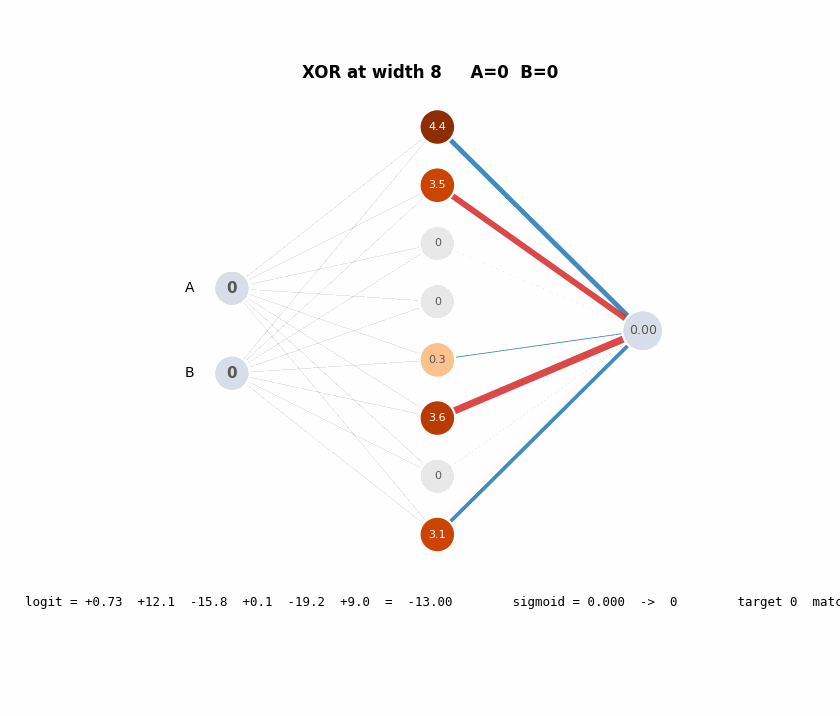


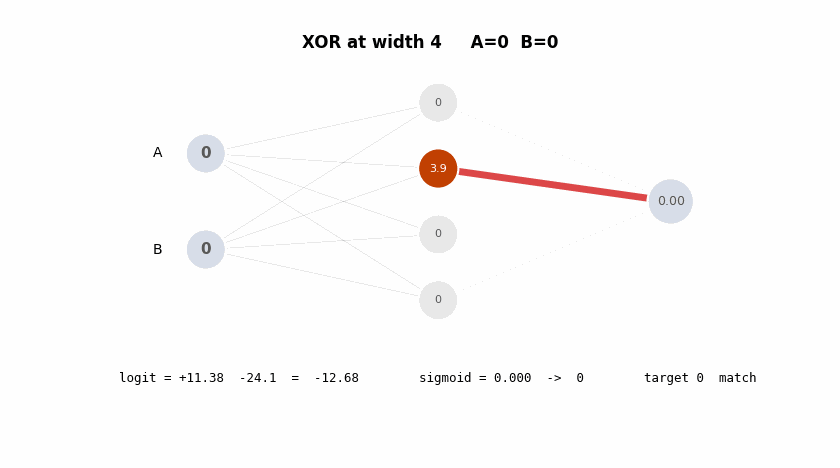


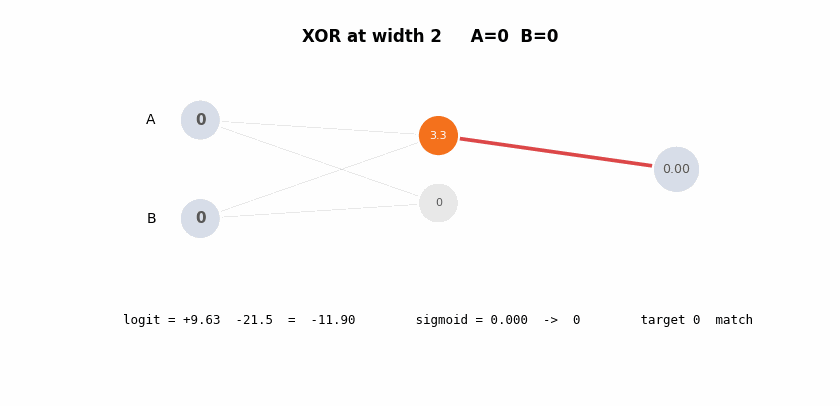

In [33]:
import base64
import os
import tempfile

from matplotlib import animation
from matplotlib.animation import PillowWriter
from IPython.display import HTML


def circuit_animation(model, function):
    """Animate a trained model computing `function`, one frame per input row."""
    width = model.net[0].out_features
    with torch.no_grad():
        hidden = torch.relu(model.net[0](INPUTS)).cpu()
        out_w = model.net[2].weight.detach()[0].cpu()
        out_b = float(model.net[2].bias.detach()[0])
    contribution = hidden * out_w
    logits = contribution.sum(dim=1) + out_b
    probs = torch.sigmoid(logits)
    target = TRUTH_TABLES[function].flatten().cpu()

    X_IN, X_HID, X_OUT = 0.0, 3.0, 6.0
    y_in = np.array([0.62, -0.62])
    y_hid = np.linspace((width - 1) / 2, -(width - 1) / 2, width) * 0.85
    span = max(float(np.abs(y_hid).max()), 0.9)
    peak_h = max(float(hidden.max()), 1e-9)
    peak_c = max(float(contribution.abs().max()), 1e-9)

    fig, ax = plt.subplots(figsize=(8.4, 2.2 + 0.62 * max(width, 3)))

    def draw(k):
        ax.clear()
        a, b = INPUTS[k].tolist()

        for j in range(width):                       # input -> hidden, static
            for yi in y_in:
                ax.plot([X_IN, X_HID], [yi, y_hid[j]], color="grey",
                        lw=0.5, alpha=0.3, zorder=1)

        for j in range(width):                       # hidden -> output, live
            c = float(contribution[k, j])
            if abs(c) > 1e-6:
                ax.plot([X_HID, X_OUT], [y_hid[j], 0.0], zorder=2, alpha=0.85,
                        color="#d62728" if c < 0 else "#1f77b4",
                        lw=0.6 + 4.5 * abs(c) / peak_c)
            else:
                ax.plot([X_HID, X_OUT], [y_hid[j], 0.0], color="grey",
                        lw=0.4, alpha=0.2, zorder=1)

        for yi, val, lab in zip(y_in, (a, b), ("A", "B")):
            on = val > 0.5
            ax.add_patch(plt.Circle((X_IN, yi), 0.26, zorder=3, ec="white", lw=1.5,
                                    color="#4C72B0" if on else "#d8dee9"))
            ax.text(X_IN, yi, str(int(val)), ha="center", va="center", zorder=4,
                    fontsize=11, fontweight="bold",
                    color="white" if on else "#555555")
            ax.text(X_IN - 0.62, yi, lab, ha="center", va="center", fontsize=10)

        for j in range(width):
            h = float(hidden[k, j])
            frac = h / peak_h
            ax.add_patch(plt.Circle((X_HID, y_hid[j]), 0.26, zorder=3, ec="white",
                                    lw=1.5, color=plt.cm.Oranges(0.25 + 0.7 * frac)
                                    if h > 1e-6 else "#e9e9e9"))
            ax.text(X_HID, y_hid[j], f"{h:.1f}" if h > 1e-6 else "0",
                    ha="center", va="center", fontsize=8, zorder=4,
                    color="white" if frac > 0.45 else "#555555")

        p = float(probs[k])
        ax.add_patch(plt.Circle((X_OUT, 0.0), 0.30, zorder=3, ec="white", lw=1.5,
                                color="#55A868" if p >= 0.5 else "#d8dee9"))
        ax.text(X_OUT, 0.0, f"{p:.2f}", ha="center", va="center", zorder=4,
                fontsize=9, color="white" if p >= 0.5 else "#555555")

        pushes = "  ".join(f"{float(contribution[k, j]):+.1f}"
                           for j in range(width) if abs(contribution[k, j]) > 1e-6)
        predicted, wanted = int(round(p)), int(target[k])
        ax.set_title(f"{function} at width {width}     A={int(a)}  B={int(b)}",
                     fontsize=12, fontweight="bold")
        ax.text(3.0, -span - 1.05,
                f"logit = {out_b:+.2f}  {pushes}  =  {float(logits[k]):+.2f}"
                f"        sigmoid = {p:.3f}  ->  {predicted}"
                f"        target {wanted}  {'match' if predicted == wanted else 'MISS'}",
                ha="center", fontsize=9, family="monospace")

        ax.set_xlim(-1.2, 7.0)
        ax.set_ylim(-span - 1.5, span + 0.6)
        ax.set_aspect("equal")
        ax.axis("off")

    anim = animation.FuncAnimation(fig, draw, frames=len(INPUTS),
                                   interval=2500, repeat=True)
    return fig, anim


def as_gif(anim, seconds_per_input=2.5):
    """Inline animated GIF - renders anywhere, including viewers that strip scripts."""
    with tempfile.TemporaryDirectory() as folder:
        path = os.path.join(folder, "circuit.gif")
        anim.save(path, writer=PillowWriter(fps=1.0 / seconds_per_input))
        with open(path, "rb") as handle:
            payload = base64.b64encode(handle.read()).decode()
    return HTML(f'<img src="data:image/gif;base64,{payload}" '
                f'style="max-width:100%" alt="circuit animation">')


for animated_width in SOLVED_WIDTHS:
    figure, anim = circuit_animation(solved[("XOR", animated_width)]["model"], "XOR")
    display(as_gif(anim))
    plt.close(figure)

---

# Closing

The question behind all of this only looks like a question about boolean functions:
when a model fails, how do you tell whether the architecture was incapable or the
training missed? Sixteen functions with four rows each is small enough to settle it.

One line per part:

1. **Baseline.** Sixteen `2 -> 8 -> 1` networks learn all sixteen functions exactly,
   64/64 bits. Non-separability barely registers - `XNOR` converges faster than `OR`.
2. **Narrowing.** Accuracy falls to 52/64. The obvious reading is that capacity ran
   out. The retry experiment shows 9 of 12 failures vanish under a different seed, so
   the obvious reading is wrong.
3. **Looking.** The loss surface shows the mechanism: a dead ReLU sits on a plateau
   whose loss varies by exactly `0.00e+00`. There is no gradient in that region at all.
4. **Fixing.** Swapping in `tanh` removes every dead layer (9 to 0) and lifts accuracy
   to 61/64. Changing the recipe instead finds a width-2 `XOR` solution too. Both leave
   the two proved impossibilities exactly where they were.
5. **Reading the circuits.** Each width-8 solution uses 1.38 of its 8 units on average.
   At width 2 the two units point in the same direction and differ only in bias - two
   kinks on one axis, which is precisely what one kink cannot do.

`XOR` and `XNOR` at width 1 are what survived every intervention. A single hidden unit
makes the network a monotone function of one linear projection, and no such function
separates a diagonal pair. That argument does not mention ReLU, Adam, the learning
rate, or the epoch budget, which is why none of them changed the outcome.

**The method, for reuse.** Three things did the work, and none are specific to boolean
functions:

- **Derive the failure values in closed form.** A dead network's loss equals the
  entropy of its labels. A monotone width-1 model's best `XOR` loss is
  $\tfrac{1}{4}(3\ln 3 - 2\ln 2)$. When a run lands on one of these to six decimals,
  the diagnosis can be read off.
- **Retry before concluding.** A success under any seed disproves a capacity limit.
  Without one, a capacity claim needs a proof, because repeated failure is equally
  consistent with bad luck. Part 4 is what happens when this is taken seriously: the
  one claim left resting on a single recipe did not survive the check.
- **Change something the theory says is irrelevant.** The activation swap in Part 4
  was chosen because the impossibility proof does not depend on it. A failure that
  survives such a change is structural.

Of the 12 failures the width sweep produced, 2 were capacity limits. The other 10 had
nothing to do with what the experiment appeared to be testing.